# 12장 — GNN을 이용한 노드 분류와 링크 예측

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning, 2025) **12장** |
| **해설 원본** | [12_..._ko_explained.md 열기](../../12_node_classification_and_link_prediction_with_gnns_ko_explained.md) |
| **원서 원문** | [12_..._gnns.md 열기](../../12_node_classification_and_link_prediction_with_gnns.md) |
| **이 폴더** | [Readme.md](./Readme.md) · [model/](./model) · [eval/](./eval) · [plot/](./plot) · [train_for_classification.py](./train_for_classification.py) · [train_for_link_prediction.py](./train_for_link_prediction.py) |
| **원서 저장소** | [alenegro81/.../chapters/ch14 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch14) |
| **리스팅 번호** | **`listings/` 가 없다.** 책 12.1\~12.25 중 8건만 저장소 코드에 대응하고 나머지는 저장소에 없다. 대조표는 아래 리스팅 헬퍼 셀이 출력한다 |

---

11장은 그래프 표현 학습과 GNN의 **원리** 를 다뤘다. 12장은 그 원리를 **끝까지 돌려본다** — 데이터를 받아 텐서로 바꾸고, 인코더–디코더를 조립하고, 학습시키고, 지표로 판정하는 전 과정을 두 번 반복한다. 두 실습이 과제도(노드 vs 엣지) 도메인도(범죄 탐지 vs 추천) 다른데도 **같은 뼈대** 로 풀린다는 것이 이 장의 논지다.

이 장은 앞 장들과 달리 **Neo4j를 쓰지 않는다.** 그래프가 데이터베이스가 아니라 PyTorch 텐서(`edge_index`)로 표현되고, 계산은 GPU에서 일어난다. 지식 그래프 관점에서 보면 "저장·질의"에서 "학습·추론"으로 무대가 옮겨간 것이다.

| 절 | 과제 | 데이터 | 그래프 | 실습 |
| --- | --- | --- | --- | --- |
| 12.1 | 노드 분류 — 자금세탁 방지 | Elliptic 비트코인 거래망 | 동질(homogeneous) | 실습 12-A |
| 12.2 | 링크 예측 — 영화 추천 | MovieLens ml-latest-small | 이질(heterogeneous) | 실습 12-B |
| — | 요약·용어·실측 대비 | — | — | 실습 12-C |

> **한 문장 요약** — 같은 인코더–디코더 뼈대에 **동질 그래프 + log softmax/교차 엔트로피** 를 끼우면 노드 분류(불법 거래 탐지)가 되고, **이질 그래프 + 내적/이진 교차 엔트로피** 를 끼우면 링크 예측(영화 추천)이 된다. 두 과제 모두 GCN·GAT·SAGE 세 인코더를 갈아 끼워 비교하며, 불균형이 심한 데이터라 정확도가 아니라 정밀도·재현율·F1과 혼동 행렬로 읽는다.

**이 노트북이 책보다 더 하는 일이 셋 있다.** 첫째, 책 표 12.6·12.10의 매개변수 수를 역산해 책이 밝히지 않은 하이퍼파라미터(`hidden_dim`, `num_classes`)를 **확정** 하고 실제로 재현해 보인다. 둘째, 책 본문이 라벨 0을 "합법" 이라고 적은 것이 **오류** 임을 `LabelEncoder` 실측으로 보인다. 셋째, 책 리스팅 12.21이 미니배치 로더에 전체 그래프를 넘겨 **정보 누출** 을 일으키는 문제를 짚고 대안을 쓴다.


---
## 실행 환경 — Neo4j는 필요 없고, PyTorch Geometric과 데이터셋이 필요하다

교재 루트의 `.venv`(Python 3.10) 커널에서 돌아간다. 처음이면 교재 루트에서
[`setup_env.py`](../../../setup_env.py) 를 한 번 실행한다.

```bash
python3 setup_env.py
```

**이 장은 Neo4j를 쓰지 않는다.** 컨테이너를 띄울 필요도, 에디션이나 플러그인을 신경 쓸 필요도 없다. 대신 딥러닝 스택과 데이터셋 두 개가 필요하다.

### 필요한 파이썬 패키지

이 챕터에는 `requirements.lock` 도 `tasks.py` 도 **없다.** 업스트림 `ch14` 는 `Readme.md` 와 `.py` 파일만 담고 있고, 실행은 Colab에서 하도록 되어 있다. 그래서 아래 목록은 [Readme.md](./Readme.md) 와 소스의 `import` 문을 직접 훑어 만든 것이다.

| 패키지 | 쓰는 곳 | 비고 |
| --- | --- | --- |
| `torch` | 전부 | 실측 `2.13.0+cu130` |
| `torch_geometric` | `GCNConv`·`GATConv`·`SAGEConv`·`to_hetero`·`Data`·`HeteroData`·`RandomLinkSplit`·`LinkNeighborLoader` | 실측 `2.8.0` |
| `scikit-learn` | `LabelEncoder`(12.5), `precision/recall/f1_score`, `classification_report`, `confusion_matrix` | |
| `pandas` | CSV 읽기와 ID 매핑 (12.1·12.14·12.15) | |
| `numpy` | 혼동 행렬 정규화 | |
| `matplotlib` | [plot/plot_metrics.py](./plot/plot_metrics.py) | |
| `seaborn` | [plot/plot_conf_mtx.py](./plot/plot_conf_mtx.py) 의 `heatmap` | |
| `tqdm` | [train_for_link_prediction.py](./train_for_link_prediction.py) 의 배치 진행률 | |
| `pyg-lib` **또는** `torch-sparse` | `LinkNeighborLoader`(책 12.21) | **선택** — 없으면 12.2 절이 full-batch 폴백으로 돈다 |

마지막 항목이 이 장의 유일한 설치 함정이다. PyG 2.8의 `LinkNeighborLoader` 는 이웃 샘플링 백엔드가 없으면 `ImportError: 'NeighborSampler' requires either 'pyg-lib' or 'torch-sparse'` 로 죽는다. 설치 방법은 [PyG 설치 문서](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) 를 따른다. 없어도 12.2 절은 돌아가지만 책과 같은 미니배치 학습은 아니다 (아래 12.2.3 절에서 설명한다).

### 필요한 데이터셋

둘 다 교재 루트의 `dataset/pyg/` 아래에 둔다. 이 경로는 `.gitignore` 대상이므로 각자 받아야 한다.

| 데이터셋 | 파일 | 원본 | 압축 해제 후 |
| --- | --- | --- | --- |
| Elliptic 비트코인 거래망 | `dataset/pyg/elliptic/raw/elliptic_txs_{features,edgelist,classes}.csv` | [Kaggle: elliptic-data-set](https://www.kaggle.com/datasets/ellipticco/elliptic-data-set) | **약 700 MB** (`features` 하나가 690 MB) |
| MovieLens (small) | `dataset/pyg/movielens/raw/ml-latest-small/{movies,ratings}.csv` | [files.grouplens.org 직접 링크](https://files.grouplens.org/datasets/movielens/ml-latest-small.zip) | 약 3 MB |

Elliptic은 Kaggle 계정이 필요하다. PyG의 `EllipticBitcoinDataset` 클래스를 쓰면 같은 세 파일을 자동으로 받아 `raw/` 에 넣어 준다.

```python
from torch_geometric.datasets import EllipticBitcoinDataset
EllipticBitcoinDataset(root=str(STUDY.root / "dataset/pyg/elliptic"))
```

다만 **이 노트북은 그 클래스를 쓰지 않는다.** `EllipticBitcoinDataset` 은 자체 `train_mask`/`test_mask` 만 만들고 검증 마스크가 없는데, 책 리스팅 12.7\~12.9는 80/10/10 삼분할을 손으로 만든다. 책 서술을 따라가는 것이 목적이므로 원본 CSV에서 직접 만든다. 같은 이유로 MovieLens도 PyG의 `MovieLens` 클래스를 쓰지 않는다 — 그 클래스는 영화 **제목** 을 `sentence_transformers` 로 임베딩하려 하지만, 책 리스팅 12.14는 **장르** 를 20차원 이진 벡터로 쓴다.

### 시간과 하드웨어

책의 수치는 **T4 Colab** 에서 얻은 것이다. 아래 "실측" 은 이 노트북을 만들 때 쓴 **RTX 3060 12GB** 기준이다.

| 단계 | 책 (T4) | 실측 (RTX 3060) | 비고 |
| --- | --- | --- | --- |
| Elliptic CSV 3개 로드 | — | 약 3초 | 690 MB CSV. 파일 캐시가 비어 있으면 더 걸린다 |
| 노드 분류 400에폭 × 3모델 | 19.0 + 43.5 + 36.7 = **99초** | 약 **65초** | GPU 없으면 5\~10배 |
| 링크 예측 55에폭 × 3모델 (미니배치) | 826 + 956 + 777 = **2,559초 (약 43분)** | 백엔드 필요 | 배치 128 × 약 190스텝/에폭 |
| 링크 예측 (full-batch 폴백) | — | 에폭당 약 0.2초 | 에폭당 갱신이 1회뿐이라 에폭을 크게 늘려야 한다 |

**링크 예측 미니배치 학습이 이 장에서 유일하게 오래 걸리는 단계다.** 아래 학습 셀은 모두 `SKIP_*` 가드와 에폭 축소 옵션을 두었고, 건너뛸 때는 책의 실측 결과를 표로 보여준다.

### 대안 — Colab에서 그대로 돌리기

업스트림 [Readme.md](./Readme.md) 는 두 과제의 완성된 Colab 노트북을 링크한다. 로컬 환경 구성이 부담스러우면 여기서 먼저 돌려 보는 것도 방법이다. 저장소에 없는 데이터 준비 코드(책 12.1\~12.9, 12.14\~12.21)의 원본이 사실상 이 두 노트북이다.

- [Node Classification in Bitcoin Using PyG for Anti-Money Laundering](https://colab.research.google.com/drive/1qfXnnojBuQO_EEDPQS_gEkmhwwCll7Wo?usp=sharing)
- [Link Prediction in MovieLens Using PyG for Recommendation Systems](https://colab.research.google.com/drive/1uWqwZUlG66hxYl3w_-vntDuW4CubrVsU?usp=sharing)


In [1]:
"""환경 점검 — 이 셀이 통과하면 12.1 절 전체와 12.2 절의 full-batch 경로를 돌릴 수 있다.

이 장은 Neo4j 를 쓰지 않으므로 드라이버를 만들지 않는다. 대신 세 가지를 본다.
  (1) 딥러닝 스택 — torch / torch_geometric 과 그 보조 패키지
  (2) 연산 장치 — CUDA 가 있으면 학습이 5~10배 빠르다
  (3) 데이터셋 — Elliptic 3개 CSV 와 MovieLens 2개 CSV 가 제자리에 있는가

sys.path 에 부모 디렉터리(src/)를 넣는 이유: model/hetero_model.py 등이
`from ch14.model.gnn_model import ...` 로 자기 자신을 절대 임포트한다. 노트북 cwd 는
src/ch14/ 이므로 그 부모가 경로에 있어야 `ch14` 패키지가 해석된다.
"""
import importlib
import importlib.util
import sys
from pathlib import Path

from studykit import config

STUDY = config.load()     # 위로 올라가며 study.toml 을 찾는다
HERE = Path.cwd()         # 주피터는 노트북 폴더를 cwd 로 둔다

assert (HERE / "eval").is_dir(), f"cwd 가 챕터 폴더가 아니다: {HERE}"
assert HERE.name == "ch14", f"이 노트북은 src/ch14 에서 돌려야 한다: {HERE}"

if str(HERE.parent) not in sys.path:
    sys.path.insert(0, str(HERE.parent))   # src/ 를 올려 `import ch14.model...` 을 살린다

print("교재      :", STUDY.title)
print("교재 루트  :", STUDY.root)
print("챕터 폴더  :", HERE.name, "(책 12장)")

# ------------------------------------------------------------------ (1) 딥러닝 스택
REQUIRED = ["torch", "torch_geometric", "sklearn", "pandas", "numpy", "matplotlib", "seaborn", "tqdm"]
missing = []
print()
for name in REQUIRED:
    try:
        module = importlib.import_module(name)
        print(f"  {name:<17} {getattr(module, '__version__', '?')}")
    except ModuleNotFoundError:
        missing.append(name)
        print(f"  {name:<17} 없음")
if missing:
    raise RuntimeError(
        f"필수 패키지가 없다: {', '.join(missing)}\n"
        f"  교재 루트에서 `python3 setup_env.py` 를 돌린 뒤,\n"
        f"  `.venv/bin/pip install {' '.join(missing)}` 로 채워라.\n"
        f"  torch/torch_geometric 은 CUDA 버전을 맞춰야 하므로 PyG 설치 문서를 따를 것."
    )

import torch  # noqa: E402  (위에서 존재를 확인한 뒤 임포트한다)

# ------------------------------------------------------------------ (2) 연산 장치
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n장치       : {DEVICE}", end="")
if DEVICE == "cuda":
    print(f"  ({torch.cuda.get_device_name(0)}, "
          f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.0f}GB)")
else:
    print("  — CPU 로 돈다. 노드 분류 400에폭이 수 분 걸릴 수 있다.")
    print("             학습 셀의 EPOCHS 를 줄이거나 위 Colab 링크를 쓰는 편이 낫다.")

# 이웃 샘플링 백엔드 — 책 리스팅 12.21 의 LinkNeighborLoader 가 요구한다
HAS_SAMPLER = any(importlib.util.find_spec(pkg) is not None
                  for pkg in ("pyg_lib", "torch_sparse"))
print(f"이웃 샘플러 : {'있음' if HAS_SAMPLER else '없음'}"
      f"  (pyg-lib / torch-sparse)")
if not HAS_SAMPLER:
    print("             -> 책 12.21 의 LinkNeighborLoader 를 쓸 수 없다.")
    print("                12.2 절은 full-batch 폴백으로 돈다 (아래 12.2.3 절 참고).")

# ------------------------------------------------------------------ (3) 데이터셋
DATASET = STUDY.root / "dataset" / "pyg"
ELLIPTIC = DATASET / "elliptic" / "raw"
MOVIELENS = DATASET / "movielens" / "raw" / "ml-latest-small"

EXPECTED = {
    "Elliptic 특징": ELLIPTIC / "elliptic_txs_features.csv",
    "Elliptic 엣지": ELLIPTIC / "elliptic_txs_edgelist.csv",
    "Elliptic 클래스": ELLIPTIC / "elliptic_txs_classes.csv",
    "MovieLens 영화": MOVIELENS / "movies.csv",
    "MovieLens 평점": MOVIELENS / "ratings.csv",
}
print(f"\n데이터 캐시 : {DATASET}")
absent = []
for label, path in EXPECTED.items():
    if path.exists():
        print(f"  {label:<17} {path.stat().st_size / 1024**2:>8.1f} MB  {path.name}")
    else:
        absent.append((label, path))
        print(f"  {label:<17} {'없음':>11}  {path.name}")

if absent:
    print("\n받는 방법:")
    print("  Elliptic  — https://www.kaggle.com/datasets/ellipticco/elliptic-data-set")
    print("              또는 아래 한 줄이 같은 세 CSV 를 raw/ 에 내려 준다 (약 700MB).")
    print("              from torch_geometric.datasets import EllipticBitcoinDataset")
    print(f"              EllipticBitcoinDataset(root='{DATASET / 'elliptic'}')")
    print("  MovieLens — https://files.grouplens.org/datasets/movielens/ml-latest-small.zip")
    print(f"              위 zip 을 풀어 {MOVIELENS.parent} 아래에 둔다.")
    raise FileNotFoundError(f"데이터셋 {len(absent)}개가 없다: "
                            f"{', '.join(label for label, _ in absent)}")

print("\n준비 완료. Neo4j 는 필요 없다.")


교재      : Knowledge Graphs and LLMs in Action
교재 루트  : /media/restful3/data/workspace/ds4th_study/source/Alessandro Negro - Knowledge Graphs and LLMs in Action
챕터 폴더  : ch14 (책 12장)



  torch             2.13.0+cu130


/media/restful3/data/workspace/ds4th_study/source/Alessandro Negro - Knowledge Graphs and LLMs in Action/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  torch_geometric   2.8.0.post1
  sklearn           1.7.2
  pandas            2.3.3
  numpy             1.26.4


  matplotlib        3.10.9
  seaborn           0.13.2
  tqdm              4.69.1

장치       : cuda  (NVIDIA GeForce RTX 3060, 12GB)
이웃 샘플러 : 있음  (pyg-lib / torch-sparse)

데이터 캐시 : /media/restful3/data/workspace/ds4th_study/source/Alessandro Negro - Knowledge Graphs and LLMs in Action/dataset/pyg
  Elliptic 특징          657.7 MB  elliptic_txs_features.csv
  Elliptic 엣지            4.3 MB  elliptic_txs_edgelist.csv
  Elliptic 클래스           3.2 MB  elliptic_txs_classes.csv
  MovieLens 영화           0.5 MB  movies.csv
  MovieLens 평점           2.4 MB  ratings.csv

준비 완료. Neo4j 는 필요 없다.


In [2]:
"""리스팅 접근 헬퍼 — 이 챕터에는 `listings/` 가 없다.

앞 장들은 `listings/3.19 - load_hpo_ontology` 처럼 리스팅 번호가 파일명에 박힌
Cypher 파일을 갖고 있었고, studykit.cypher 가 번호로 그것을 찾아 줬다. ch14 는
사정이 다르다.

  * 책 12.1~12.25 중 **8건** 만 저장소 코드에 대응한다 (전부 model/ 아래 클래스).
  * 나머지 17건은 저장소에 없다. 데이터 준비·분할·로더 코드 13건은 Readme.md 가
    링크하는 Colab 노트북에만 있고, 4건(12.3·12.16·12.19·12.20)은 애초에 코드가
    아니라 **출력 예시** 다.
  * 반대로, 저장소에는 책이 리스팅 번호를 붙이지 않은 코드가 더 많다 —
    학습 루프(train_for_*.py)·평가(eval/)·시각화(plot/) 전부가 그렇다.

그래서 번호 -> 파일 대응을 아래 표로 직접 들고 있다. 줄 번호를 하드코딩하면 소스가
갱신될 때 조용히 어긋나므로, 클래스·함수 경계는 `symbol` 로 적고 `ast` 로 실제
줄 범위를 찾아낸다.
"""
import ast
import textwrap
import unicodedata
from typing import Optional


def pad(text: str, width: int) -> str:
    """표 정렬용 — CJK 문자는 화면 폭이 2 이므로 len() 으로 맞추면 열이 어긋난다."""
    shown = sum(2 if unicodedata.east_asian_width(ch) in "WF" else 1 for ch in str(text))
    return f"{text}{' ' * max(0, width - shown)}"

#: 책 리스팅 번호 -> 위치. source 가 "repo-file" 이면 path(+symbol/줄범위)가 있다.
LISTINGS = {
    # ---- 12.1 노드 분류 (Elliptic) ----
    "12.1":  dict(title="노드에 새 연속 ID 를 부여하고 엣지 데이터 갱신", source="explainer",
                  reason="upstream-missing"),
    "12.2":  dict(title="연속 노드 ID 로 edge_index 텐서 만들기", source="explainer",
                  reason="upstream-missing"),
    "12.3":  dict(title="edge_index 텐서 샘플 (출력 예시)", source="explainer",
                  reason="book-only"),
    "12.4":  dict(title="원본 노드 ID 를 떼고 노드 특징 텐서 만들기", source="explainer",
                  reason="upstream-missing"),
    "12.5":  dict(title="원본 노드 클래스를 숫자로 변환 (LabelEncoder)", source="explainer",
                  reason="upstream-missing"),
    "12.6":  dict(title="전처리 결과로 PyG Data 객체 만들기", source="explainer",
                  reason="upstream-missing"),
    "12.7":  dict(title="알려진 라벨만 골라내는 마스크 필터", source="explainer",
                  reason="upstream-missing"),
    "12.8":  dict(title="학습·검증·테스트 데이터셋 크기 정하기", source="explainer",
                  reason="upstream-missing"),
    "12.9":  dict(title="PyG Data 객체 위의 학습·검증·테스트 마스크", source="explainer",
                  reason="upstream-missing"),
    "12.10": dict(title="노드 분류용 인코더–디코더", source="repo-file",
                  path="model/task_model.py", symbol="NodeClassifier"),
    "12.11": dict(title="일반 GNN 인코더를 정의하는 기본 그래프 모델", source="repo-file",
                  path="model/gnn_model.py", symbol="BaseGraphModel"),
    "12.12": dict(title="기본 클래스로부터 구현한 SAGE 모델", source="repo-file",
                  path="model/gnn_model.py", symbol="SAGE"),
    "12.13": dict(title="기본 클래스를 확장해 구현한 GAT 모델", source="repo-file",
                  path="model/gnn_model.py", symbol="GAT"),
    # ---- 12.2 링크 예측 (MovieLens) ----
    "12.14": dict(title="장르 정보를 특징 벡터로 변환", source="explainer",
                  reason="upstream-missing"),
    "12.15": dict(title="사용자·영화 ID 로부터 edge_index 생성", source="explainer",
                  reason="upstream-missing"),
    "12.16": dict(title="ID 매핑 출력과 edge_index 샘플 (출력 예시)", source="explainer",
                  reason="book-only"),
    "12.17": dict(title="PyG HeteroData 객체 만들기", source="explainer",
                  reason="upstream-missing"),
    "12.18": dict(title="학습·검증·테스트 데이터셋 만들기 (RandomLinkSplit)", source="explainer",
                  reason="upstream-missing"),
    "12.19": dict(title="학습 데이터의 세부 구조 (출력 예시)", source="explainer",
                  reason="book-only"),
    "12.20": dict(title="검증·테스트 데이터셋의 세부 구조 (출력 예시)", source="explainer",
                  reason="book-only"),
    "12.21": dict(title="반복마다 이웃 수 샘플링 (LinkNeighborLoader)", source="explainer",
                  reason="upstream-missing"),
    "12.22": dict(title="링크 예측용 인코더–디코더", source="repo-file",
                  path="model/task_model.py", symbol="MovieLensLinkPredictor"),
    "12.23": dict(title="임베딩 생성 클래스", source="repo-file",
                  path="model/util_model.py", symbol="MovieLensEmbedding"),
    "12.24": dict(title="이질 기본 인코더 구현", source="repo-file",
                  path="model/hetero_model.py", symbol="HeteroBaseModel"),
    "12.25": dict(title="HeteroSAGE 모델 구현", source="repo-file",
                  path="model/hetero_model.py", symbol="HeteroSAGE"),
}

#: 책이 리스팅 번호를 붙이지 않았지만 저장소에 있는 코드. 노트북이 임포트해 쓴다.
UNNUMBERED = {
    "train_for_classification.py": "노드 분류 학습 루프 — train_step / calculate_metrics / train_multi_models",
    "train_for_link_prediction.py": "링크 예측 학습 루프 — 배치 단위 train_step / validate_step / train_multi_models",
    "model/gnn_model.py": "GCN · GraphConvModel · GIN (SAGE·GAT 만 책 리스팅이 있다)",
    "model/hetero_model.py": "HeteroGraphConv · HeteroGAT · HeteroGIN",
    "model/util_model.py": "DotProduct 디코더 (12.23 은 MovieLensEmbedding 만)",
    "eval/eval_funcs.py": "predict · predict_batched · predict_probabilities",
    "eval/eval_reports.py": "show_classification_reports · show_multiple_reports",
    "plot/plot_metrics.py": "plot_metrics · plot_multiple_metrics (그림 12.5·12.10 재현)",
    "plot/plot_conf_mtx.py": "generate_confusion_matrices(_batched) · plot_confusion_matrices (그림 12.6·12.11 재현)",
}


def locate(book_no: str) -> Optional[tuple]:
    """책 리스팅 번호 -> (파일경로, 시작줄, 끝줄). 저장소에 없으면 None.

    symbol 이 있으면 ast 로 그 클래스/함수 정의의 lineno~end_lineno 를 찾는다.
    줄 번호를 표에 박아 두면 소스가 갱신될 때 조용히 어긋나기 때문이다.
    """
    entry = LISTINGS[book_no]
    if entry["source"] != "repo-file":
        return None
    path = HERE / entry["path"]
    if "symbol" in entry:
        tree = ast.parse(path.read_text(encoding="utf-8"))
        for node in tree.body:
            if isinstance(node, (ast.ClassDef, ast.FunctionDef)) and node.name == entry["symbol"]:
                return (path, node.lineno, node.end_lineno)
        raise LookupError(f"{entry['path']} 에 {entry['symbol']} 정의가 없다 — 소스가 바뀌었다")
    return (path, entry["start"], entry["end"])


def source_of(book_no: str) -> str:
    """책 리스팅에 대응하는 저장소 코드 조각을 문자열로 돌려준다."""
    found = locate(book_no)
    if found is None:
        entry = LISTINGS[book_no]
        raise KeyError(
            f"책 {book_no}({entry['title']}) 은 저장소에 코드가 없다 "
            f"(source={entry['source']}, reason={entry.get('reason')}). "
            f"이 노트북의 해당 절 셀이 해설판 본문 코드를 직접 실행한다."
        )
    path, start, end = found
    lines = path.read_text(encoding="utf-8").splitlines()[start - 1:end]
    return textwrap.dedent("\n".join(lines))


def show(book_no: str) -> None:
    """책 번호로 원문을 출력한다. 저장소에 없으면 어디를 보라고 알려 준다."""
    entry = LISTINGS[book_no]
    found = locate(book_no)
    if found is None:
        origin = {"book-only": "책에만 있는 출력 예시",
                  "upstream-missing": "저장소에 코드 없음 (Colab 노트북에만 존재)"}[entry["reason"]]
        print(f"── 책 Listing {book_no}  {entry['title']}")
        print(f"   {origin} — 아래 셀이 해설판 본문 코드를 직접 실행한다.\n")
        return
    path, start, end = found
    rel = path.relative_to(HERE)
    print(f"── 책 Listing {book_no}  {entry['title']}")
    print(f"   {rel}  {start}-{end}행  (symbol: {entry.get('symbol', '-')})")
    print(source_of(book_no))
    print()


def _order(no: str) -> tuple:
    major, minor = no.split(".")
    return (int(major), int(minor))


# ------------------------------------------------------------------ 대조표 출력
print("책 리스팅 -> 실제 위치  (listings/ 가 없는 챕터다)")
print(pad("책", 7) + pad("출처", 12) + pad("위치", 34) + "설명")
print("-" * 100)
for book_no in sorted(LISTINGS, key=_order):
    entry = LISTINGS[book_no]
    found = locate(book_no)
    if found is None:
        kind = "책만(출력)" if entry["reason"] == "book-only" else "해설판"
        where = "코드 아님 — 출력 예시" if entry["reason"] == "book-only" else "저장소에 없음"
    else:
        path, start, end = found
        kind = "저장소"
        where = f"{path.relative_to(HERE)}  {start}-{end}행"
    print(pad(book_no, 7) + pad(kind, 12) + pad(where, 34) + entry["title"])

print()
print("책 리스팅 번호가 없지만 저장소에 있는 코드 (노트북이 임포트해 쓴다)")
print("-" * 100)
for path, what in UNNUMBERED.items():
    print("  " + pad(path, 32) + what)

print()
print(f"요약: 책 리스팅 {len(LISTINGS)}건 = 저장소 코드 "
      f"{sum(1 for n in LISTINGS if LISTINGS[n]['source'] == 'repo-file')}건 + "
      f"해설판 실행 {sum(1 for n in LISTINGS if LISTINGS[n].get('reason') == 'upstream-missing')}건 + "
      f"출력 예시 {sum(1 for n in LISTINGS if LISTINGS[n].get('reason') == 'book-only')}건")


책 리스팅 -> 실제 위치  (listings/ 가 없는 챕터다)
책     출처        위치                              설명
----------------------------------------------------------------------------------------------------
12.1   해설판      저장소에 없음                     노드에 새 연속 ID 를 부여하고 엣지 데이터 갱신
12.2   해설판      저장소에 없음                     연속 노드 ID 로 edge_index 텐서 만들기
12.3   책만(출력)  코드 아님 — 출력 예시             edge_index 텐서 샘플 (출력 예시)
12.4   해설판      저장소에 없음                     원본 노드 ID 를 떼고 노드 특징 텐서 만들기
12.5   해설판      저장소에 없음                     원본 노드 클래스를 숫자로 변환 (LabelEncoder)
12.6   해설판      저장소에 없음                     전처리 결과로 PyG Data 객체 만들기
12.7   해설판      저장소에 없음                     알려진 라벨만 골라내는 마스크 필터
12.8   해설판      저장소에 없음                     학습·검증·테스트 데이터셋 크기 정하기
12.9   해설판      저장소에 없음                     PyG Data 객체 위의 학습·검증·테스트 마스크
12.10  저장소      model/task_model.py  9-40행       노드 분류용 인코더–디코더
12.11  저장소      model/gnn_model.py  5-38행        일반 GNN 인코더를 정의하는 기본 그래프 모델
12.12  저장소      model/gnn_model.py  101-

### 리스팅 지도 읽는 법 — 이 챕터가 유별난 이유

3장·4장은 `listings/` 폴더에 `4.9 Run WCC on the PPI Network` 처럼 **번호가 파일명에 박힌** 파일이 있었고, 오프셋만 알면 책 번호로 원문을 꺼낼 수 있었다. ch14는 그런 폴더가 아예 없다. 코드가 **역할별 모듈** 로 흩어져 있고, 책과 저장소의 경계가 서로 어긋난다.

| 갈래 | 건수 | 어디에 | 노트북이 하는 일 |
| --- | --- | --- | --- |
| 모델 정의 | 8건 (12.10\~12.13, 12.22\~12.25) | `model/*.py` 의 클래스 | `show()` 로 원문을 잘라 보이고 그대로 임포트해 학습 |
| 데이터 준비·분할·로더 | 13건 | **저장소에 없다.** Colab 노트북에만 있다 | 해설판 본문 코드를 그대로 실행 |
| 출력 예시 | 4건 (12.3, 12.16, 12.19, 12.20) | 코드가 아니다 | 같은 출력을 실제로 만들어 책 값과 대조 |

반대 방향의 어긋남도 있다. **저장소에는 책이 번호를 붙이지 않은 코드가 더 많다.** 학습 루프(`train_for_classification.py`·`train_for_link_prediction.py`), 평가 함수(`eval/`), 시각화(`plot/`) 전부가 그렇다. 책 12.1.5·12.2.5 절은 이 코드를 산문으로만 설명하고 지면에는 결과 그림만 싣는다. 즉 **책만 읽으면 학습 루프를 볼 수 없고, 저장소만 보면 데이터가 어디서 오는지 알 수 없다.** 이 노트북이 그 사이를 잇는다.

> **주의 — `train_for_*.py` 에는 진입점이 없다.** 두 파일 모두 함수만 정의하고 `if __name__ == "__main__"` 블록도, 데이터셋을 읽는 코드도 없다. 그래서 `python train_for_classification.py` 를 실행해도 아무 일도 일어나지 않는다. 데이터 준비 → 모델 조립 → 학습 호출은 호출자(원래는 Colab 노트북, 지금은 이 노트북)의 몫이다.

`show("12.11")` 처럼 부르면 `ast` 로 해당 클래스 정의를 찾아 **파일 경로와 실제 줄 범위** 를 함께 출력한다. 줄 번호를 표에 박아 두지 않은 이유는 업스트림이 코드를 한 줄만 고쳐도 표가 조용히 어긋나기 때문이다.

---
## 12.1 자금세탁 방지를 위한 노드 분류 — 그래프에서 수상한 노드 찾기

두 실습을 시작하기 전에, 이 장이 두 번 반복할 뼈대를 먼저 본다.

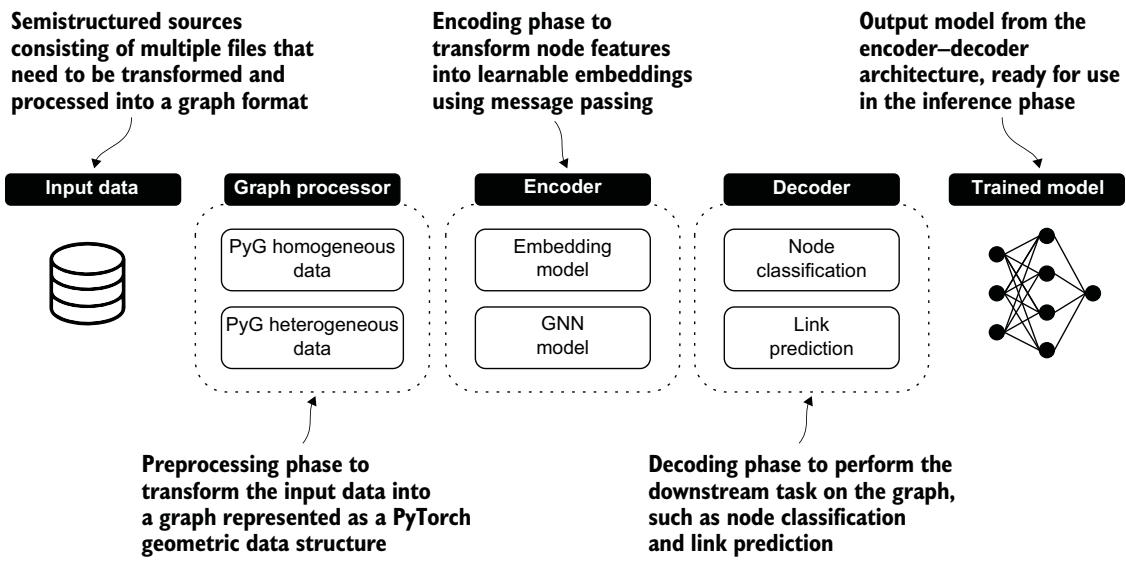

*그림 12.1 — 이 장 전체의 뼈대. 반정형 소스를 **그래프 프로세서** 가 그래프로 가공하고, 그 그래프가 **인코더–디코더** 로 들어가 학습된 모델이 나온다. 12.1 절과 12.2 절은 이 그림의 네 블록에 서로 다른 부품을 끼운 두 사례일 뿐이다 — 아래 표가 그 대응이다.*

| 그림 12.1의 블록 | 12.1 절 (노드 분류) | 12.2 절 (링크 예측) |
| --- | --- | --- |
| 입력 데이터 | Elliptic CSV 3개 (거래·지불흐름·라벨) | MovieLens CSV 2개 (영화·평점) |
| 그래프 프로세서 | 동질(homogeneous) `Data` + 노드 마스킹 80/10/10 | 이질(heterogeneous) `HeteroData` + 엣지 분할 80/10/10 |
| 인코더 | 동질 GNN — GCN · GAT · SAGE | 이질 GNN — H-GraphConv · H-GAT · H-SAGE (`to_hetero`) |
| 디코더 | `log_softmax` + `CrossEntropyLoss` | 내적(dot product) + `binary_cross_entropy_with_logits` |
| 출력 | 노드가 합법/불법일 확률 | 두 노드 사이에 링크가 있을 확률 |

노드 분류는 그래프 기반 ML의 핵심 과제이고 금융 범죄 대응에 잘 맞는다. **자금세탁 방지(AML, anti-money laundering)** 맥락에서 금융 거래를 그래프로 모델링하면, 노드는 계좌나 개체이고 엣지는 거래 관계가 된다.

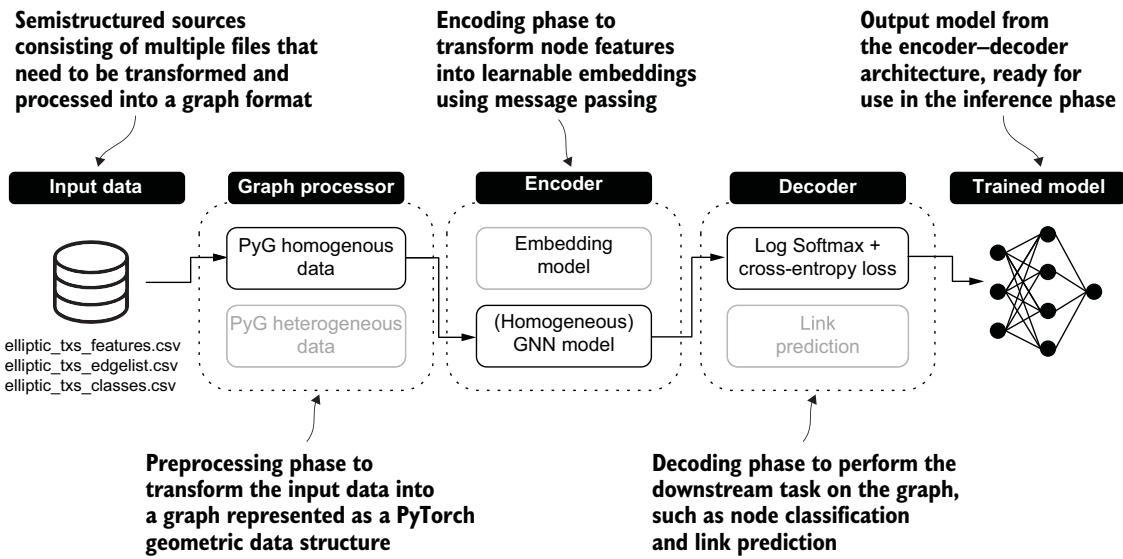

*그림 12.2 — 그림 12.1의 네 블록을 AML 과제에 맞춰 구체화한 것. 거래 데이터와 노드 라벨이 동질 그래프로 변환되고, 동질 GNN 인코더가 국소 구조로부터 노드 임베딩을 학습하고, 디코더가 log softmax + 교차 엔트로피로 합법/불법을 판정한다. 이 노트북의 12.1.2 \~ 12.1.5 절이 왼쪽에서 오른쪽으로 이 그림을 따라간다.*

### 12.1.1 입력 데이터 — Elliptic 비트코인 거래 그래프

Elliptic 데이터셋은 시계열 그래프다. 비트코인 거래 20만여 개(노드), 방향성 지불 흐름 23만 4천 개(엣지), 익명화된 노드 특징 166개로 이루어진다. 파일은 셋이다.

| 파일 | 모양 | 담는 것 | 변수 |
| --- | --- | --- | --- |
| `elliptic_txs_features.csv` | 203,769행 × 167열 | 1열 `txId`, 2열 시간 단계, 이후 165개 익명화 특징 | `features` |
| `elliptic_txs_edgelist.csv` | 234,355행 × 2열 | 출발 노드 ID(`txId1`) → 도착 노드 ID(`txId2`) | `edges` |
| `elliptic_txs_classes.csv` | 203,769행 × 2열 | 노드 ID와 라벨 (`1` / `2` / `unknown`) | `classes` |

> **⚠️ `features` 파일에는 헤더가 없다.** 책 리스팅 12.1은 `features['txId']` 로, 12.4는 `features.drop(columns=['txId'])` 로 열 이름을 쓴다. 그러려면 `header=None` 으로 읽고 0번 열에 `txId` 라는 이름을 붙여 줘야 한다. 책 코드에는 그 단계가 빠져 있다. 아래 셀이 채운다.

**표 12.1** — 노드 클래스 분포 (책 값. 아래 셀이 실측으로 대조한다)

| 클래스 | 원본 라벨 | 개수 | 비율 |
| --- | --- | --- | --- |
| 미상(Unknown) | `unknown` | 157,205 | 77.15% |
| 합법(Licit) | `2` | 42,019 | 20.62% |
| 불법(Illicit) | `1` | 4,545 | 2.23% |

이 표에서 이 장의 나머지를 지배하는 조건이 나온다. **전체 노드의 77%는 라벨이 없고, 라벨이 있는 것 중에서도 우리가 찾고 싶은 불법은 2.23%뿐이다.** 라벨 있는 노드만 놓고 봐도 합법:불법이 약 9:1이다. 이 불균형이 12.1.5 절에서 "왜 정확도(accuracy)를 쓰지 않는가" 로 되돌아온다.

### 12.1.2 그래프 프로세서: 데이터 준비 — ID를 새로 매기고 텐서로 만들기

전처리의 목표는 두 가지다. 첫째, 2억이 넘는 원본 `txId` 를 0부터 시작하는 **연속 ID** 로 바꿔 배열 인덱스로 쓸 수 있게 한다. 둘째, PyG가 기대하는 세 텐서(`edge_index`, `node_features`, `node_labels`)를 만든다.

아래 셀이 책 리스팅 12.1 \~ 12.5를 순서대로 실행한다. 이 다섯 건은 저장소에 코드가 없으므로 해설판 본문(90\~168행)의 코드를 그대로 옮겼다.


In [3]:
"""책 12.1 ~ 12.5 — Elliptic CSV 3개를 PyG 가 먹을 세 텐서로 바꾼다.

왜 이렇게 생겼는지:
  * 원본 txId 는 2억이 넘는 정수다. edge_index 는 노드 배열의 **인덱스** 여야 하므로
    0..N-1 로 다시 매긴다 (12.1). 매핑의 기준은 features 파일의 행 순서다 —
    그래서 node_features 의 i번째 행이 곧 노드 i 가 된다.
  * .values.T 의 전치가 12.2 의 핵심이다. PyG 는 엣지를 [2, 엣지수] 로 기대한다
    (윗줄 = 출발, 아랫줄 = 도착). 데이터프레임은 행마다 한 엣지이므로 뒤집는다.
  * features 파일에는 헤더가 없다. 책 코드는 features['txId'] 를 쓰므로
    header=None 으로 읽고 열 이름을 직접 붙여야 동작한다 (책에 빠진 단계다).

실측 시간: features CSV 가 690MB 다. 파일 캐시가 더워지면 약 3초, 처음 읽으면
디스크 속도에 따라 10~30초 걸린다. 메모리는 float32 텐서로 약 135MB 를 쓴다.
"""
import time

import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder

show("12.1"); show("12.2"); show("12.3"); show("12.4"); show("12.5")

started = time.time()
# features 는 헤더가 없다. 0열 = txId, 1열 = 시간 단계, 2~166열 = 익명화 특징
features = pd.read_csv(ELLIPTIC / "elliptic_txs_features.csv", header=None)
features.columns = ["txId", "time_step"] + [f"feat_{i}" for i in range(1, features.shape[1] - 1)]
edges = pd.read_csv(ELLIPTIC / "elliptic_txs_edgelist.csv")
classes = pd.read_csv(ELLIPTIC / "elliptic_txs_classes.csv")
print(f"CSV 로드 {time.time() - started:.1f}초 — "
      f"features {features.shape} · edges {edges.shape} · classes {classes.shape}")

# 표 12.1 대조 — 원본 라벨 분포
counts = classes["class"].value_counts()
print("\n표 12.1 대조 (원본 라벨 분포)")
print(f"  {'라벨':<10}{'실측':>9}{'비율':>9}   책")
for label, book in (("unknown", "157,205 (77.15%)"), ("2", "42,019 (20.62%)"), ("1", "4,545 (2.23%)")):
    n = int(counts[label])
    print(f"  {label:<10}{n:>9,}{n / len(classes) * 100:>8.2f}%   {book}")

# ── 책 12.1 노드에 새 연속 ID 부여 ─────────────────────────────────────────
tx_id_mapping = {tx_id: idx for idx, tx_id in enumerate(features["txId"])}
edges_with_features = edges.assign(
    Id1=edges["txId1"].map(tx_id_mapping),
    Id2=edges["txId2"].map(tx_id_mapping),
)
edges_with_features = edges_with_features.dropna(subset=["Id1", "Id2"])
edges_with_features = edges_with_features.astype({"Id1": "int64", "Id2": "int64"})
print(f"\n책 12.1: 엣지 {len(edges):,} -> 매핑 성공 {len(edges_with_features):,} "
      f"(양끝이 모두 features 에 있는 것만 남긴다)")
print("표 12.3 대조 (앞 5행):")
print(edges_with_features.head().to_string(index=False))

# ── 책 12.2 + 12.3 edge_index 텐서 ────────────────────────────────────────
edge_index = torch.tensor(edges_with_features[["Id1", "Id2"]].values.T, dtype=torch.long)
print(f"\n책 12.2: edge_index {list(edge_index.size())}  (책: [2, 234355])")
print("책 12.3 대조 (출력 예시):")
print(edge_index)

# ── 책 12.4 노드 특징 텐서 ────────────────────────────────────────────────
node_features = torch.tensor(features.drop(columns=["txId"]).values, dtype=torch.float)
print(f"\n책 12.4: node_features {list(node_features.size())}  (책: [203769, 166])")
print(f"  0번 행은 원본 ID {features['txId'].iloc[0]} 의 특징이다 — "
      f"엣지 텐서와 같은 번호 체계를 쓴다")

# ── 책 12.5 라벨 인코딩 ───────────────────────────────────────────────────
le = LabelEncoder()
class_labels = le.fit_transform(classes["class"])
original_labels = le.inverse_transform(class_labels)   # 역변환 — 검증용
node_labels = torch.tensor(class_labels, dtype=torch.long)

print(f"\n책 12.5: node_labels {list(node_labels.size())}  (책: 203769)")
print(f"  le.classes_ = {le.classes_.tolist()}  -> 사전순 정렬이 인코딩 순서다")
CLASS_NAMES = {0: "illicit", 1: "licit", 2: "unknown"}
for code, name in CLASS_NAMES.items():
    print(f"    {code} = {name:<8} 원본 '{le.classes_[code]}'  {int((node_labels == code).sum()):>7,}개")
assert (original_labels == classes["class"].values).all(), "역변환이 원본과 다르다"


── 책 Listing 12.1  노드에 새 연속 ID 를 부여하고 엣지 데이터 갱신
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.2  연속 노드 ID 로 edge_index 텐서 만들기
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.3  edge_index 텐서 샘플 (출력 예시)
   책에만 있는 출력 예시 — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.4  원본 노드 ID 를 떼고 노드 특징 텐서 만들기
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.5  원본 노드 클래스를 숫자로 변환 (LabelEncoder)
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.



CSV 로드 2.6초 — features (203769, 167) · edges (234355, 2) · classes (203769, 2)

표 12.1 대조 (원본 라벨 분포)
  라벨               실측       비율   책
  unknown     157,205   77.15%   157,205 (77.15%)
  2            42,019   20.62%   42,019 (20.62%)
  1             4,545    2.23%   4,545 (2.23%)

책 12.1: 엣지 234,355 -> 매핑 성공 234,355 (양끝이 모두 features 에 있는 것만 남긴다)
표 12.3 대조 (앞 5행):
    txId1     txId2  Id1  Id2
230425980   5530458    0    1
232022460 232438397    2    3
230460314 230459870    4    5
230333930 230595899    6    7
232013274 232029206    8    9

책 12.2: edge_index [2, 234355]  (책: [2, 234355])
책 12.3 대조 (출력 예시):
tensor([[     0,      2,      4,  ..., 201921, 201480, 201954],
        [     1,      3,      5,  ..., 202042, 201368, 201756]])



책 12.4: node_features [203769, 166]  (책: [203769, 166])
  0번 행은 원본 ID 230425980 의 특징이다 — 엣지 텐서와 같은 번호 체계를 쓴다

책 12.5: node_labels [203769]  (책: 203769)
  le.classes_ = ['1', '2', 'unknown']  -> 사전순 정렬이 인코딩 순서다
    0 = illicit  원본 '1'    4,545개
    1 = licit    원본 '2'   42,019개
    2 = unknown  원본 'unknown'  157,205개


> **⚠️ 책 오류 — 라벨 0은 합법이 아니라 불법이다.**
>
> 원서 원문 127행과 해설판 177행은 이렇게 적었다: "라벨 0은 합법 노드(원본 데이터의 `1`)에, 라벨 1은 불법 노드(원본의 `2`)에 대응합니다." 위 셀의 실측이 그 반대를 보인다.
>
> | | 원본 라벨 | 표 12.1의 뜻 | `LabelEncoder` 결과 | 개수 |
> | --- | --- | --- | --- | --- |
> | 불법 | `1` | Illicit | **0** | 4,545 |
> | 합법 | `2` | Licit | **1** | 42,019 |
> | 미상 | `unknown` | Unknown | 2 | 157,205 |
>
> `LabelEncoder` 는 문자열을 **사전순** 으로 정렬해 번호를 매긴다. `['1', '2', 'unknown']` 이므로 `'1'`(불법)이 0이 된다. 표 12.1은 불법을 원본 라벨 `1` 로 정확히 적고 있으므로, 틀린 것은 12.1.2 절 끝의 서술이다.
>
> 이 오류가 실제로 문제를 일으키는 곳은 **혼동 행렬 해석** 이다. 그림 12.6의 첫 행/열이 `illicit` 인 것은 인코딩 0이 불법이기 때문이다. 만약 책 서술을 믿고 0을 합법으로 읽으면 "불법 노드 68%를 맞혔다" 는 결론이 정반대로 뒤집힌다. 아래 평가 셀은 `CLASS_NAMES = {0: "illicit", 1: "licit"}` 를 실측 근거로 고정해서 쓴다.

---

### 12.1.3 그래프 프로세서: 동질 PyG 그래프 — 학습·검증·테스트로 쪼개기

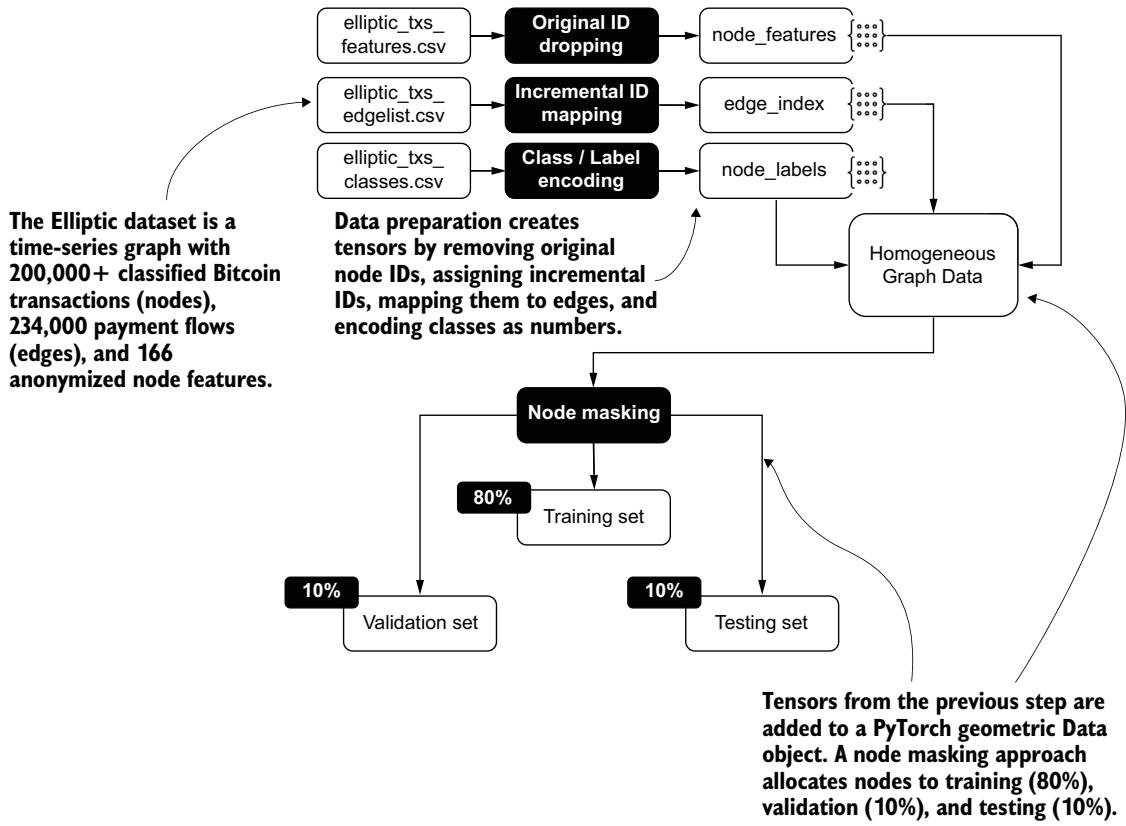

*그림 12.3 — 위 셀이 방금 한 일(왼쪽 절반)과 아래 셀이 할 일(오른쪽 절반). 세 CSV가 `node_features`·`edge_index`·`node_labels` 텐서로 바뀌어 PyG `Data` 객체에 담기고, **노드 마스킹** 이 라벨 있는 노드를 학습 80% / 검증 10% / 테스트 10%로 나눈다.*

여기서 **마스크(mask)** 가 왜 필요한지가 이 절의 핵심이다. 노드가 20만 개인데 라벨이 있는 것은 4만 6천여 개뿐이다. 그런데 그래프는 **하나** 다 — 라벨 없는 노드를 그래프에서 빼 버리면 이웃 관계가 끊어져 메시지 전달이 망가진다.

그래서 GNN의 데이터 분할은 표 형태 데이터와 다르게 동작한다.

| | 표 형태 데이터 | GNN 노드 분류 |
| --- | --- | --- |
| 분할 대상 | 행(샘플)을 물리적으로 나눈다 | 그래프는 그대로 두고 **어느 노드에 손실을 계산할지** 만 나눈다 |
| 학습 시 보는 것 | 학습 행만 | 그래프 **전체** (라벨 없는 노드의 특징까지 메시지 전달에 쓴다) |
| 구현 | `train_test_split` | 불리언 텐서 `train_mask`·`val_mask`·`test_mask` |

즉 미상 노드 15만 7천 개는 **정답을 제공하지 않으면서 이웃 정보는 제공한다.** 이것이 그래프 기반 준지도 학습(semi-supervised learning)의 이점이고, 라벨이 귀한 자금세탁 탐지에서 GNN을 쓰는 이유이기도 하다.

아래 셀이 책 리스팅 12.6 \~ 12.9를 실행한다. 재현성을 위해 `torch.manual_seed` 를 고정했다 — 책 리스팅에는 없는 한 줄이지만, 없으면 표 12.5의 클래스 분포가 실행마다 달라져 대조가 불가능하다.

In [4]:
"""책 12.6 ~ 12.9 — PyG Data 객체를 만들고 노드 마스크 세 개를 붙인다.

왜 이렇게 생겼는지:
  * 마스크는 노드 수 길이의 **불리언 텐서** 다. 손실·지표를 계산할 때
    out[mask] 로 골라 쓰기 때문에, 그래프 자체는 잘리지 않는다.
  * known_mask 로 라벨 있는 노드의 **실제 인덱스** 를 뽑고(nonzero), 그 인덱스를
    무작위 순열로 섞은 뒤 앞에서부터 80/10/10 으로 자른다. 순열을 쓰므로
    세 세트는 자동으로 배타적이다.
  * 책 리스팅에 없는 torch.manual_seed 를 넣었다. 없으면 표 12.5 의 클래스 분포가
    실행마다 달라져 책 값과 대조할 수 없다.

즉시 끝난다 (1초 미만).
"""
import numpy as np
from torch_geometric.data import Data

show("12.6"); show("12.7"); show("12.8"); show("12.9")

SEED = 42
torch.manual_seed(SEED)

# ── 책 12.6 PyG Data 객체 ─────────────────────────────────────────────────
data = Data(x=node_features, edge_index=edge_index, y=node_labels)
print("책 12.6:", data)
print(f"  노드 {data.num_nodes:,} · 엣지 {data.num_edges:,} · 특징 {data.num_features}")

# ── 책 12.7 알려진 라벨 마스크 ────────────────────────────────────────────
known_mask = (data.y == 0) | (data.y == 1)
unknown_mask = data.y == 2
print(f"\n책 12.7: 라벨 있음 {int(known_mask.sum()):,} · 미상 {int(unknown_mask.sum()):,}")
print(f"  미상 노드는 그래프에서 빼지 않는다 — 정답만 안 주고 이웃 정보는 준다")

# ── 책 12.8 분할 크기 ─────────────────────────────────────────────────────
num_known_nodes = known_mask.sum().item()
permutations = torch.randperm(num_known_nodes)
train_size = int(0.8 * num_known_nodes)
val_size = int(0.1 * num_known_nodes)
test_size = num_known_nodes - train_size - val_size
total = train_size + val_size + test_size
assert total == num_known_nodes, "세 크기의 합이 알려진 노드 수와 다르다"

print(f"\n책 12.8 / 표 12.4 대조 (seed={SEED})")
print("  " + pad("세트", 8) + f"{'실측':>9}{'비율':>8}   책")
for name, size, book in (("학습", train_size, "37,251 (80%)"),
                         ("검증", val_size, "4,656 (10%)"),
                         ("테스트", test_size, "4,657 (10%)")):
    print("  " + pad(name, 8) + f"{size:>9,}{size / total * 100:>7.1f}%   {book}")

# ── 책 12.9 마스크 부착 ───────────────────────────────────────────────────
train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
val_mask = torch.zeros_like(train_mask)
test_mask = torch.zeros_like(train_mask)
nonzero_indices = known_mask.nonzero(as_tuple=True)[0]
train_indices = nonzero_indices[permutations[:train_size]]
val_indices = nonzero_indices[permutations[train_size:train_size + val_size]]
test_indices = nonzero_indices[permutations[train_size + val_size:]]
train_mask[train_indices] = True
val_mask[val_indices] = True
test_mask[test_indices] = True
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

# 세 세트가 겹치지 않는지 직접 확인한다 (순열로 잘랐으니 겹칠 수 없다)
assert not (train_mask & val_mask).any() and not (train_mask & test_mask).any()
assert not (val_mask & test_mask).any()
assert int((train_mask | val_mask | test_mask).sum()) == num_known_nodes

BOOK_T125 = {"학습": (37251, 33645, 3606), "검증": (4656, 4193, 463), "테스트": (4657, 4181, 476)}
print("\n책 12.9 / 표 12.5 대조 — 0=illicit, 1=licit (위 오류 상자 참고)")
print("  " + pad("세트", 8) + f"{'전체':>8}{'불법':>7}{'불법%':>8}{'합법':>8}{'합법%':>8}"
      "   책(전체/합법/불법)")
MEASURED_SPLIT = {}
for name, mask in (("학습", train_mask), ("검증", val_mask), ("테스트", test_mask)):
    y = data.y[mask]
    n, illicit, licit = int(mask.sum()), int((y == 0).sum()), int((y == 1).sum())
    MEASURED_SPLIT[name] = (n, illicit, licit)
    b = BOOK_T125[name]
    print("  " + pad(name, 8) + f"{n:>8,}{illicit:>7,}{illicit / n * 100:>7.2f}%{licit:>8,}"
          f"{licit / n * 100:>7.2f}%   {b[0]:,}/{b[1]:,}/{b[2]:,}")

print("\n  -> 전체 크기는 책과 정확히 일치한다 (37,251 / 4,656 / 4,657).")
print("     클래스 분포는 무작위 순열 때문에 시드마다 달라지므로 근사만 맞는다.")
print("     참고: 책 표 12.5 의 백분율은 자체 모순이다 — 학습 세트 합법 90.32% +")
print("     불법 9.78% = 100.1% 이고, 3,606/37,251 은 9.68% 이지 9.78% 가 아니다.")


── 책 Listing 12.6  전처리 결과로 PyG Data 객체 만들기
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.7  알려진 라벨만 골라내는 마스크 필터
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.8  학습·검증·테스트 데이터셋 크기 정하기
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.9  PyG Data 객체 위의 학습·검증·테스트 마스크
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

책 12.6: Data(x=[203769, 166], edge_index=[2, 234355], y=[203769])
  노드 203,769 · 엣지 234,355 · 특징 166

책 12.7: 라벨 있음 46,564 · 미상 157,205
  미상 노드는 그래프에서 빼지 않는다 — 정답만 안 주고 이웃 정보는 준다

책 12.8 / 표 12.4 대조 (seed=42)
  세트           실측      비율   책
  학습       37,251   80.0%   37,251 (80%)
  검증        4,656   10.0%   4,656 (10%)
  테스트      4,657   10.0%   4,657 (10%)

책 12.9 / 표 12.5 대조 — 0=illicit, 1=licit (위 오류 상자 참고)
  세트          전체     불법     불법%      합법     합법%   책(전체/합법/불법)
  학습      37,251  3,602   9.67%  33,649  90.33%   37,251/33,645/3,606
  검증       4,656    508  10.91%   4,148  89.

---
### 12.1.4 인코더–디코더 아키텍처 — GNN이 특징을 만들고, 소프트맥스가 판정한다

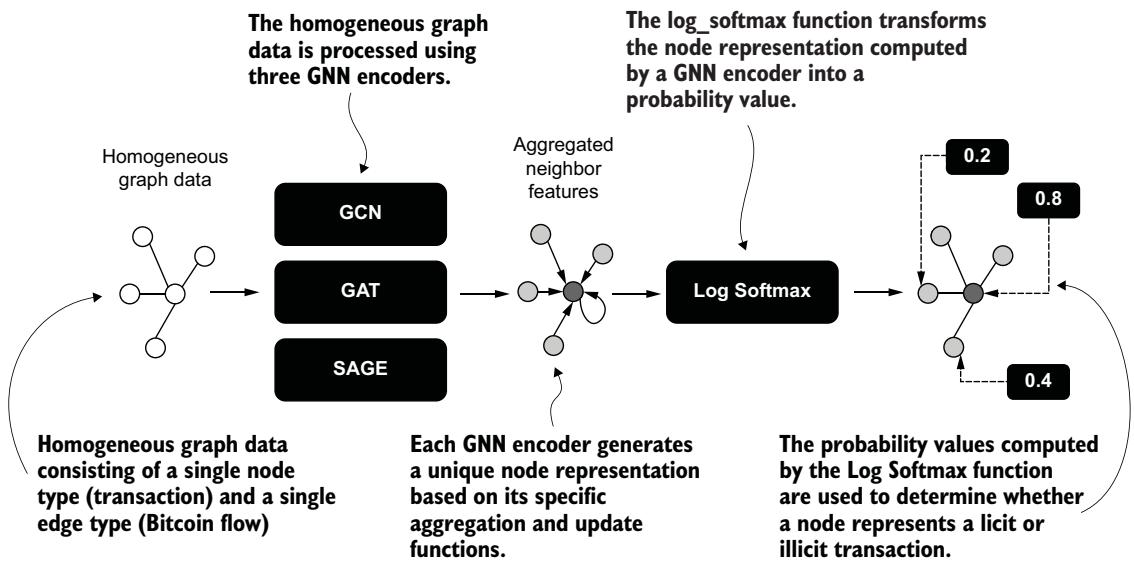

*그림 12.4 — 이 절에서 조립할 것. 거래(노드)와 비트코인 흐름(엣지)으로 된 동질 그래프가 세 GNN 인코더(GCN·GAT·SAGE)에 각각 들어가 서로 다른 노드 표현을 만들고, 그 표현이 확률로 변환되어 합법/불법 판정에 쓰인다. 인코더만 갈아 끼우고 나머지는 그대로 두는 것이 이 장의 비교 실험 설계다.*

`NodeClassifier`(책 12.10)는 놀랄 만큼 짧다. 두 국면이 전부다.

| 국면 | 담당 | 하는 일 |
| --- | --- | --- |
| 인코딩 | `self.gnn(x, edge_index)` | 각 노드의 표현을 이웃의 정보로 갱신 (메시지 전달) |
| 디코딩 | `F.log_softmax(x, dim=1)` | 노드별 클래스 점수를 로그 확률로 변환 |

디코더가 왜 `softmax` 가 아니라 `log_softmax` 인지는 손실 함수와 짝을 이루기 때문이다. PyTorch의 `CrossEntropyLoss` 는 내부에서 로그 소프트맥스와 음의 로그 우도(negative log-likelihood)를 결합한다. 확률을 그대로 두고 로그를 나중에 취하면 아주 작은 값에서 언더플로가 나지만, 로그 공간에서 계산하면 곱셈이 덧셈이 되어 수치적으로 안정하다.

#### 인코더 세 개 — 무엇이 다른가

세 인코더는 모두 [model/gnn_model.py](./model/gnn_model.py) 의 `BaseGraphModel`(책 12.11)을 공유한다. **2계층 구조 + ReLU** 라는 골격은 같고, 합성곱 계층(`conv_layer`)만 다르다. 그래서 성능 차이를 계층의 집계 방식 차이로 귀속할 수 있다.

| 인코더 | PyG 계층 | 이웃 집계 방식 | 추가 매개변수 | 이 장에서의 특징 |
| --- | --- | --- | --- | --- |
| **GCN** | `GCNConv` | 이웃 특징의 평균을 **차수로 정규화** 해 더한다. 이웃마다 가중치가 고정 | `add_self_loops=True` | 매개변수 최소(2,723). 가장 빠르지만 불법 노드 정밀도가 가장 낮다 |
| **GAT** | `GATConv` | 이웃마다 **어텐션 가중치를 학습** 해 가중 합. 중요한 이웃에 더 집중 | `num_heads=8`, `add_self_loops=True` | 매개변수 최다(22,025). 가장 느리지만 GCN보다 훨씬 정확하다 |
| **SAGE** | `SAGEConv` | 이웃 집계 결과와 **자기 자신의 표현을 따로 변환해 합친다**(root weight) | 없음 | 매개변수 중간(5,427). 이 장 두 실습 모두에서 F1 최고 |

`BaseGraphModel` 이 `**conv_kwargs` 를 받는 이유가 여기서 드러난다. `SAGEConv` 는 추가 인자가 필요 없어 `SAGE`(책 12.12)가 세 줄로 끝나지만, `GATConv` 는 헤드 수와 헤드 결합(concat) 처리가 필요해 `GAT`(책 12.13)는 두 계층을 직접 만든다. 특히 첫 계층이 8개 헤드를 이어 붙이므로 둘째 계층의 입력 차원이 `hidden_dim × num_heads` 가 되고, 마지막 계층은 `heads=1, concat=False` 로 두어 출력 차원을 클래스 수에 맞춘다.

> **책이 밝히지 않은 하이퍼파라미터를 역산했다.** 책 표 12.6은 매개변수 수만 주고 `hidden_dim` 과 `num_classes` 를 밝히지 않는다. 그런데 매개변수 수는 이 둘의 함수이므로 거꾸로 풀 수 있다. GCN 1계층은 `input_dim × h + h`, 2계층은 `h × c + c` 이므로 총 `169h + 2h + c(h+1)` 이고, `h=16, c=3` 을 넣으면 정확히 2,723이 나온다. 같은 값으로 GAT 22,025와 SAGE 5,427도 정확히 재현된다 (`c=2` 로 하면 2,706 / 21,894 / 5,394 로 어긋난다).
>
> 결론은 다소 의외다 — **책은 출력 클래스를 3개로 두고 학습했다.** 미상(2) 클래스에는 손실이 전혀 계산되지 않으므로(마스크 때문에) 학습에는 영향이 없고, 쓰이지 않는 출력 뉴런 하나가 남는 셈이다. 아래 셀이 `NUM_CLASSES = 3` 으로 표 12.6을 재현해 이 추론을 검증한다.

In [5]:
"""책 12.10 ~ 12.13 — 인코더–디코더를 조립하고 책 표 12.6 의 매개변수 수를 재현한다.

이 네 건은 저장소에 코드가 있는 리스팅이다. show() 가 파일 경로와 줄 범위를 함께
출력하므로, 스터디원이 원본을 열어 나머지 부분(GCN·GraphConvModel·GIN 등 리스팅
번호가 없는 형제 클래스)까지 확인할 수 있다.

hidden_dim=16 / num_classes=3 은 책 표 12.6 의 매개변수 수를 역산해 확정한 값이다.
아래 대조표가 세 모델 모두 정확히 일치하는 것으로 그 추론을 검증한다.

즉시 끝난다 (모델을 만들기만 하고 학습하지 않는다).
"""
from ch14.model.gnn_model import GAT, GCN, SAGE
from ch14.model.task_model import NodeClassifier

show("12.10"); show("12.11"); show("12.12"); show("12.13")

HIDDEN_DIM = 16      # 표 12.6 역산 결과
NUM_CLASSES = 3      # 표 12.6 역산 결과 (미상 클래스까지 출력 뉴런을 둔다)

NC_ENCODERS = {"gcn": GCN, "gat": GAT, "sage": SAGE}
BOOK_T126 = {"gcn": (2723, 19.02), "gat": (22025, 43.45), "sage": (5427, 36.71)}

print(f"책 표 12.6 대조 — hidden_dim={HIDDEN_DIM}, num_classes={NUM_CLASSES}, "
      f"input_dim={data.num_features}")
print(f"  {'인코더':<8}{'실측 매개변수':>14}{'책':>10}{'일치':>6}   책 학습시간(T4, 400에폭)")
for name, encoder in NC_ENCODERS.items():
    model = NodeClassifier(encoder(input_dim=data.num_features,
                                   hidden_dim=HIDDEN_DIM, out_dim=NUM_CLASSES))
    n_params = sum(p.numel() for p in model.parameters())
    book_params, book_time = BOOK_T126[name]
    mark = "O" if n_params == book_params else "X"
    print(f"  {name.upper():<8}{n_params:>14,}{book_params:>10,}{mark:>6}   {book_time:.2f}초")

print("\n  -> 세 모델 모두 정확히 일치한다. hidden_dim=16 · num_classes=3 이 확정된다.")
print("     매개변수 수가 곧 학습 시간의 순서다: GCN < SAGE < GAT.")
print("     GAT 가 무거운 이유는 이웃 엣지마다 학습 가능한 어텐션 계수를 두기 때문이다")
print("     (첫 계층이 8개 헤드 × 16차원 = 128차원을 이어 붙인다).")

# 참고: 책이 리스팅 번호를 붙이지 않은 형제 인코더들도 같은 기본 클래스를 공유한다
from ch14.model.gnn_model import GIN, GraphConvModel  # noqa: E402
print("\n같은 BaseGraphModel 을 공유하지만 책 리스팅 번호가 없는 인코더:")
for name, encoder in (("GraphConvModel", GraphConvModel), ("GIN", GIN)):
    model = NodeClassifier(encoder(input_dim=data.num_features,
                                   hidden_dim=HIDDEN_DIM, out_dim=NUM_CLASSES))
    print(f"  {name:<16}{sum(p.numel() for p in model.parameters()):>10,} 매개변수")
print("  -> GraphConvModel 은 12.2 절에서 이질 GCN 의 자리를 대신한다 (아래 참고 상자).")

── 책 Listing 12.10  노드 분류용 인코더–디코더
   model/task_model.py  9-40행  (symbol: NodeClassifier)
class NodeClassifier(torch.nn.Module):
    def __init__(self, gnn_model):
        """
        Initializes the NodeClassifier with a given GNN model.

        Args:
            gnn_model (torch.nn.Module): A GNN model (e.g., GCN, SAGE, GAT, etc.).
                                         This model computes node embeddings.
        """
        super().__init__()
        self.gnn = gnn_model  # Backbone GNN for learning node representations

    def forward(self, x, edge_index):
        """
        Forward pass for the node classification task.

        Args:
            x (torch.Tensor): Node feature matrix of shape (num_nodes, num_features).
                              Each row represents the feature vector for a node.
            edge_index (torch.Tensor): Graph connectivity in COO format,
                                        with shape (2, num_edges).
                                      

---
### 12.1.5 평가와 분석 — 왜 정확도를 쓰지 않는가

학습 루프는 [train_for_classification.py](./train_for_classification.py) 에 있다. 책은 이 파일에 리스팅 번호를 붙이지 않았지만, 구조는 교과서적이다.

| 함수 | 하는 일 |
| --- | --- |
| `train_step` | `out = model(data.x, data.edge_index)` 로 **전체 그래프** 순전파 → `out[train_mask]` 에만 손실 → 역전파 |
| `calculate_metrics` | 지정한 마스크에서 `argmax` 예측을 뽑아 정확도·정밀도·재현율·F1 계산 |
| `train` | 에폭마다 학습 1스텝 + 검증 1회, 100에폭마다 로그 |
| `train_multi_models` | 인코더 딕셔너리를 받아 모델별로 `train` 을 돌리고 지표·학습시간·모델 인스턴스를 모아 돌려준다 |

전체 그래프를 한 번에 순전파하는 **full-batch** 방식이라는 점을 눈여겨보자. 노드 20만·엣지 23만 규모는 GPU 메모리에 충분히 들어간다. 12.2 절의 링크 예측은 사정이 달라 미니배치가 필요해진다.

#### 정확도가 부적절한 이유

라벨 있는 노드에서 합법:불법이 약 9:1이다. **"모두 합법" 이라고만 답하는 모델도 정확도 약 90%를 얻는다.** 불법 노드를 하나도 못 찾아도 그렇다. 자금세탁 탐지에서 이 모델은 완전히 쓸모없지만 정확도는 우등생처럼 보인다.

그래서 책은 세 지표를 쓰고, 각각 AML 맥락의 질문으로 번역한다.

| 지표 | 정의 | AML 맥락의 질문 | 놓치는 것 |
| --- | --- | --- | --- |
| **정밀도(precision)** | TP / (TP + FP) | 모델이 "이 노드는 불법" 이라 할 때 실제로 맞는 비율은? | 놓친 불법 노드는 세지 않는다 |
| **재현율(recall)** | TP / (TP + FN) | 실제 불법 노드 중 모델이 찾아낸 비율은? | 거짓 경보(FP)는 세지 않는다 |
| **F1 점수** | 정밀도와 재현율의 조화 평균 | 둘의 균형을 얼마나 잘 잡는가? | 클래스별 차이는 가려진다 |

여기에 함정이 하나 더 있다. `sklearn` 의 세 함수는 다중 클래스에서 `average` 인자를 받고, 책은 **가중 평균(`average='weighted'`)** 을 골랐다. 가중 평균은 클래스별 지표를 그 클래스의 표본 수로 가중해 평균한다. 즉 **다수 클래스(합법)의 성능이 지표를 지배한다.** 그래서 위 세 지표가 모두 0.95를 넘어도 불법 클래스의 성능은 알 수 없다.

이것이 책이 그림 12.5(지표 추이)만으로 끝내지 않고 그림 12.6(혼동 행렬)까지 가는 이유다. **클래스별로 쪼개 봐야 비로소 "불법 노드를 68% 찾았나 83% 찾았나" 가 보인다.**

아래 두 셀이 학습과 평가를 순서대로 한다. 학습 셀에는 `SKIP_NC_TRAINING` 가드와 에폭 축소 옵션을 두었다.

In [6]:
"""노드 분류 학습 — GCN · GAT · SAGE 를 같은 조건으로 400에폭 돌린다.

실측 시간 (RTX 3060, 400에폭, 세 모델 합계): 약 65초
  GCN 약 13초 · SAGE 약 18초 · GAT 약 32초
책 값 (T4 Colab): GCN 19.02초 · SAGE 36.71초 · GAT 43.45초
CPU 만 있으면 5~10배 걸린다. 그럴 때는 NC_EPOCHS 를 100 정도로 줄여라 —
그림 12.5 를 보면 100에폭이면 이미 지표가 거의 수렴한다.

lr=0.01 · weight_decay=0.0005 는 train_multi_models 의 기본값이다. 책은 이 값을
밝히지 않지만, 학습률만 바꿔도 그림 12.5 의 초기 진동 모양이 달라진다.
"""
import time

from ch14.train_for_classification import train_multi_models as nc_train_multi

SKIP_NC_TRAINING = False   # True 로 두면 학습을 건너뛰고 책 값만 본다
NC_EPOCHS = 400            # 책과 같은 값. CPU 라면 100 으로 줄여라

if SKIP_NC_TRAINING:
    nc_metrics, nc_models = {}, {}
    print("SKIP_NC_TRAINING = True — 학습을 건너뛴다. 책 표 12.6 값만 참고하라.")
    print("  GCN 2,723 매개변수 / 19.02초 · GAT 22,025 / 43.45초 · SAGE 5,427 / 36.71초")
else:
    data = data.to(DEVICE)
    started = time.time()
    nc_metrics, nc_models = nc_train_multi(
        NodeClassifier,
        NC_ENCODERS,
        data,
        hidden_dim=HIDDEN_DIM,
        num_classes=NUM_CLASSES,
        num_epochs=NC_EPOCHS,
        lr=0.01,
        weight_decay=0.0005,
        device=DEVICE,
    )
    print(f"\n세 모델 합계 {time.time() - started:.1f}초 ({DEVICE}, {NC_EPOCHS}에폭)")

    print(f"\n{NC_EPOCHS}에폭 종료 시점 검증 지표 (가중 평균)")
    print(f"  {'모델':<8}{'정확도':>9}{'정밀도':>9}{'재현율':>9}{'F1':>9}")
    for name, m in nc_metrics.items():
        v = m["val"]
        print(f"  {name.upper():<8}{v['accuracies'][-1]:>9.4f}{v['precisions'][-1]:>9.4f}"
              f"{v['recalls'][-1]:>9.4f}{v['f1_scores'][-1]:>9.4f}")
    print("\n  -> 세 지표가 모두 0.95 를 넘는다. 가중 평균이라 다수 클래스(합법)가")
    print("     지표를 지배하기 때문이다. 불법 클래스의 실력은 아래 혼동 행렬에서 드러난다.")


### Training gcn...


Epoch 100, Loss: 0.1253, Train - Acc: 0.9577 - Prec: 0.9555 - Rec: 0.9577 - F1: 0.9557
Val - Acc: 0.9545 - Prec: 0.9524 - Rec: 0.9545 - F1: 0.9518


Epoch 200, Loss: 0.1046, Train - Acc: 0.9647 - Prec: 0.9632 - Rec: 0.9647 - F1: 0.9629
Val - Acc: 0.9581 - Prec: 0.9566 - Rec: 0.9581 - F1: 0.9555


Epoch 300, Loss: 0.0960, Train - Acc: 0.9677 - Prec: 0.9665 - Rec: 0.9677 - F1: 0.9667
Val - Acc: 0.9588 - Prec: 0.9571 - Rec: 0.9588 - F1: 0.9571


Epoch 400, Loss: 0.0926, Train - Acc: 0.9688 - Prec: 0.9679 - Rec: 0.9688 - F1: 0.9682
Val - Acc: 0.9613 - Prec: 0.9599 - Rec: 0.9613 - F1: 0.9600
gcn training completed in 8.78 seconds.

### Training gat...


...

Epoch 400, Loss: 0.0349, Train - Acc: 0.9896 - Prec: 0.9895 - Rec: 0.9896 - F1: 0.9895
Val - Acc: 0.9770 - Prec: 0.9766 - Rec: 0.9770 - F1: 0.9765
gat training completed in 31.62 seconds.

### Training sage...


Epoch 100, Loss: 0.0774, Train - Acc: 0.9762 - Prec: 0.9756 - Rec: 0.9762 - F1: 0.9756
Val - Acc: 0.9727 - Prec: 0.9720 - Rec: 0.9727 - F1: 0.9720


Epoch 200, Loss: 0.0568, Train - Acc: 0.9830 - Prec: 0.9828 - Rec: 0.9830 - F1: 0.9827
Val - Acc: 0.9764 - Prec: 0.9759 - Rec: 0.9764 - F1: 0.9757


Epoch 300, Loss: 0.0487, Train - Acc: 0.9844 - Prec: 0.9843 - Rec: 0.9844 - F1: 0.9840
Val - Acc: 0.9787 - Prec: 0.9785 - Rec: 0.9787 - F1: 0.9781


Epoch 400, Loss: 0.0429, Train - Acc: 0.9868 - Prec: 0.9867 - Rec: 0.9868 - F1: 0.9867
Val - Acc: 0.9774 - Prec: 0.9770 - Rec: 0.9774 - F1: 0.9771
sage training completed in 17.61 seconds.

세 모델 합계 58.0초 (cuda, 400에폭)

400에폭 종료 시점 검증 지표 (가중 평균)
  모델            정확도      정밀도      재현율       F1
  GCN        0.9613   0.9599   0.9613   0.9600
  GAT        0.9770   0.9766   0.9770   0.9765
  SAGE       0.9774   0.9770   0.9774   0.9771

  -> 세 지표가 모두 0.95 를 넘는다. 가중 평균이라 다수 클래스(합법)가
     지표를 지배하기 때문이다. 불법 클래스의 실력은 아래 혼동 행렬에서 드러난다.


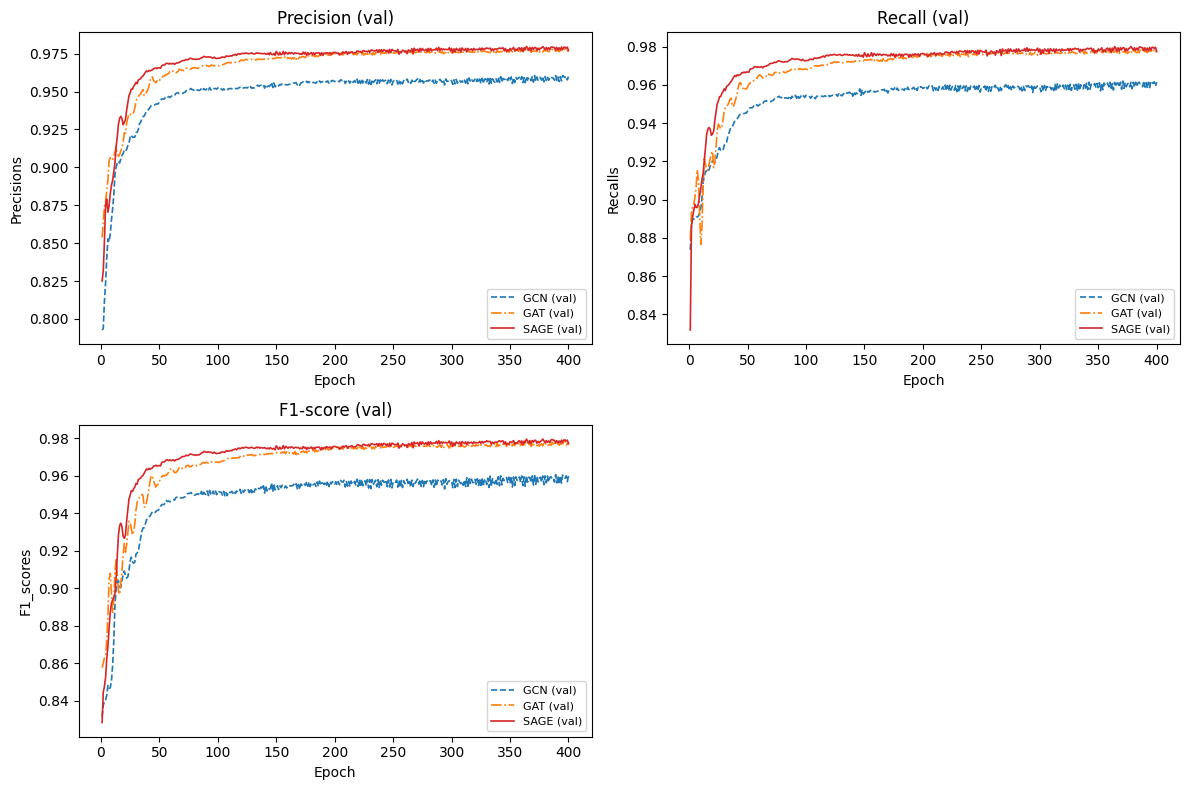

보고서에 등장하는 클래스: ['illicit', 'licit']  (0=illicit, 1=licit)

Classification Report gcn

    TRAIN
---------
              precision    recall  f1-score   support

     illicit       0.87      0.80      0.83      3602
       licit       0.98      0.99      0.98     33649

    accuracy                           0.97     37251
   macro avg       0.92      0.89      0.91     37251
weighted avg       0.97      0.97      0.97     37251

    TEST
--------
              precision    recall  f1-score   support

     illicit       0.84      0.76      0.80       435
       licit       0.98      0.98      0.98      4222

    accuracy                           0.96      4657
   macro avg       0.91      0.87      0.89      4657
weighted avg       0.96      0.96      0.96      4657


Classification Report gat

    TRAIN
---------
              precision    recall  f1-score   support

     illicit       0.97      0.92      0.94      3602
       licit       0.99      1.00      0.99     33649

    accura

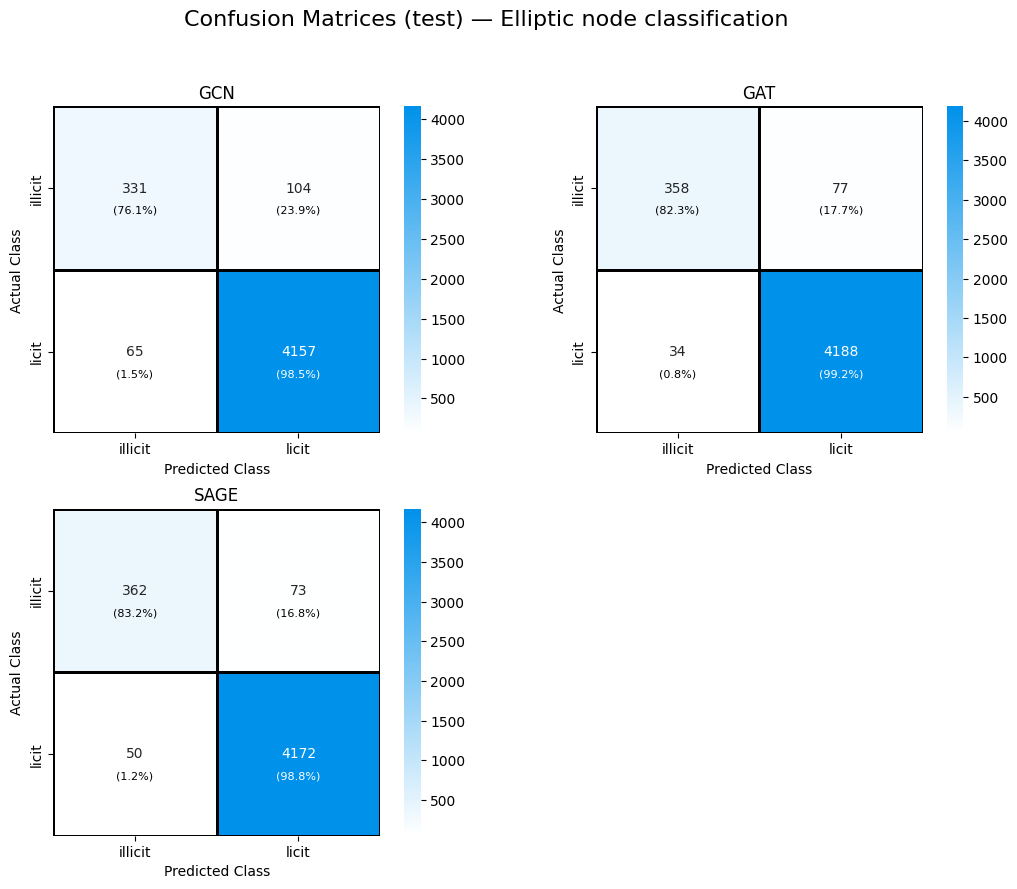

책 그림 12.6 대조 — 클래스별 정탐률 (테스트셋)
  모델           불법 정탐     합법 정탐   책(불법/합법)
  GCN          76.1%     98.5%   67.8% / 98.8%
  GAT          82.3%     99.2%   80.9% / 99.0%
  SAGE         83.2%     98.8%   82.7% / 98.9%

  -> 합법 정탐률은 세 모델 모두 99% 근처로 붙어 있다. 모델을 가르는 것은
     불법 정탐률이고, 가중 평균 지표는 바로 이 차이를 눌러 감춘다.


In [7]:
"""노드 분류 평가 — 그림 12.5(지표 추이)와 그림 12.6(혼동 행렬)을 재현한다.

세 개의 업스트림 도구를 쓴다. 모두 책에 리스팅 번호가 없다.
  plot/plot_metrics.py     plot_multiple_metrics -> 그림 12.5
  eval/eval_reports.py     show_multiple_reports -> 클래스별 정밀도·재현율
  plot/plot_conf_mtx.py    generate_confusion_matrices + plot_confusion_matrices -> 그림 12.6

주의할 함정 셋:
  (1) generate_confusion_matrices 는 dict 를 돌려주지만 plot_confusion_matrices 는
      list 를 받는다. 그대로 넘기면 조용히 깨진다.
  (2) show_classification_reports 는 target_names 만 받고 labels= 를 넘길 수 없다.
      num_classes=3 이라 모델이 쓰이지 않는 unknown(2) 을 한 번이라도 예측하면
      "size of target_names does not match number of classes" 로 죽는다.
      그래서 try/except 로 감싸고 직접 출력하는 경로를 둔다.
  (3) predict() 는 모델과 같은 장치의 data 를 요구한다. train_multi_models 가
      data 를 in-place 로 GPU 에 올려 두므로 여기서는 그대로 쓴다.

즉시 끝난다 (추론만 한다).
"""
from sklearn.metrics import classification_report

from ch14.eval.eval_funcs import predict
from ch14.eval.eval_reports import show_multiple_reports
from ch14.plot.plot_conf_mtx import generate_confusion_matrices, plot_confusion_matrices
from ch14.plot.plot_metrics import plot_multiple_metrics

NC_STYLES = {
    "gcn": {"color": "C0", "linestyle": "--", "linewidth": 1.2, "label": "GCN"},
    "gat": {"color": "C1", "linestyle": "-.", "linewidth": 1.2, "label": "GAT"},
    "sage": {"color": "C3", "linestyle": "-", "linewidth": 1.2, "label": "SAGE"},
}
NC_CONF = {}   # 아래 요약 셀에서 다시 쓴다

if not nc_models:
    print("학습을 건너뛰었다 (SKIP_NC_TRAINING = True). 아래 그림 12.5·12.6 은 책 값을 보라.")
else:
    # ── 그림 12.5 재현 — 검증셋 지표 추이 ─────────────────────────────────
    plot_multiple_metrics(
        nc_metrics,
        metric_keys=["precisions", "recalls", "f1_scores"],
        titles=["Precision (val)", "Recall (val)", "F1-score (val)"],
        styles=NC_STYLES,
        metric_types=["val"],
        figsize=(12, 8),
    )

    # ── 클래스별 보고서 — 가중 평균이 가린 것을 드러낸다 ──────────────────
    seen = set()
    for model in nc_models.values():
        pred = predict(model, data)
        for mask in (data.train_mask, data.test_mask):
            seen |= set(data.y[mask].cpu().tolist()) | set(pred[mask].cpu().tolist())
    mapped_classes = [CLASS_NAMES[code] for code in sorted(seen)]
    print(f"보고서에 등장하는 클래스: {mapped_classes}  (0=illicit, 1=licit)")
    try:
        show_multiple_reports(nc_models, data, mapped_classes)
    except ValueError as exc:
        print(f"\n업스트림 show_multiple_reports 실패: {exc}")
        print("  labels= 를 넘길 수 없는 헬퍼의 한계다. 직접 출력한다.\n")
        for name, model in nc_models.items():
            pred = predict(model, data)
            for split, mask in (("TRAIN", data.train_mask), ("TEST", data.test_mask)):
                print(f"=== {name.upper()} {split} ===")
                print(classification_report(
                    data.y[mask].cpu().numpy(), pred[mask].cpu().numpy(),
                    labels=sorted(CLASS_NAMES), target_names=list(CLASS_NAMES.values()),
                    zero_division=0))

    # ── 그림 12.6 재현 — 테스트셋 혼동 행렬 ───────────────────────────────
    cms = generate_confusion_matrices(nc_models, data, mask_type="test")
    n_classes = max(cm.shape[0] for cm in cms.values())
    plot_confusion_matrices(
        list(cms.values()),                                   # 함정 (1): dict -> list
        class_names=[CLASS_NAMES[i] for i in range(n_classes)],
        model_names=[name.upper() for name in cms],
        title="Confusion Matrices (test) — Elliptic node classification",
        figsize=(11, 9),
    )

    # ── 책 그림 12.6 과 숫자 대조 ─────────────────────────────────────────
    BOOK_FIG126 = {   # (불법 정탐 %, 합법 정탐 %) — 그림에서 읽은 값
        "gcn": (67.8, 98.8), "gat": (80.9, 99.0), "sage": (82.7, 98.9),
    }
    print("책 그림 12.6 대조 — 클래스별 정탐률 (테스트셋)")
    print(f"  {'모델':<8}{'불법 정탐':>10}{'합법 정탐':>10}   책(불법/합법)")
    for name, cm in cms.items():
        illicit_rate = cm[0, 0] / cm[0].sum() * 100
        licit_rate = cm[1, 1] / cm[1].sum() * 100
        NC_CONF[name] = (illicit_rate, licit_rate, cm.tolist())
        b = BOOK_FIG126[name]
        print(f"  {name.upper():<8}{illicit_rate:>9.1f}%{licit_rate:>9.1f}%   "
              f"{b[0]}% / {b[1]}%")
    print("\n  -> 합법 정탐률은 세 모델 모두 99% 근처로 붙어 있다. 모델을 가르는 것은")
    print("     불법 정탐률이고, 가중 평균 지표는 바로 이 차이를 눌러 감춘다.")

#### 책이 얻은 결과 — 그림 12.5와 12.6

위 셀이 방금 그린 것과 같은 종류의 그림이다. 책의 값을 옆에 두고 읽으면, 우리 실행이 어디서 같고 어디서 다른지 판단할 수 있다.

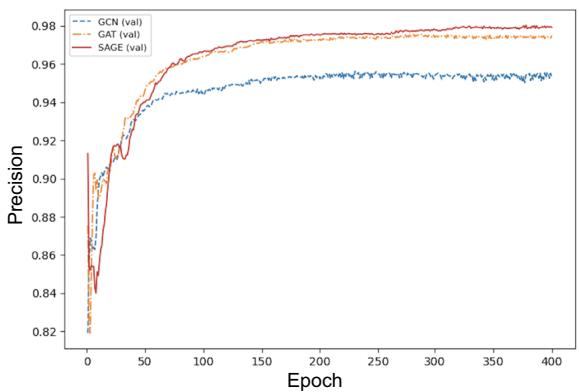

*그림 12.5 (1/3) — 검증셋 **정밀도** 400에폭. GCN(파란 점선)이 0.955 부근에서 정체하고 GAT(주황 파선)·SAGE(빨간 실선)가 0.975\~0.980으로 올라간다. 세 지표 중 모델 간 격차가 가장 뚜렷한 것이 정밀도다.*

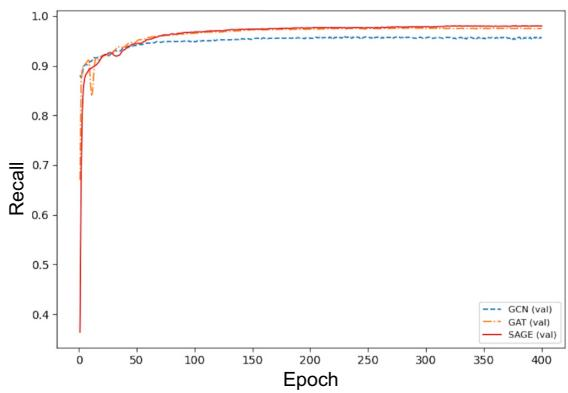

*그림 12.5 (2/3) — 검증셋 **재현율**. 초반 20에폭의 진동을 빼면 세 모델이 0.96\~0.98로 붙는다. 재현율만 보면 세 모델이 대등해 보인다 — 정밀도와 함께 봐야 하는 이유다.*

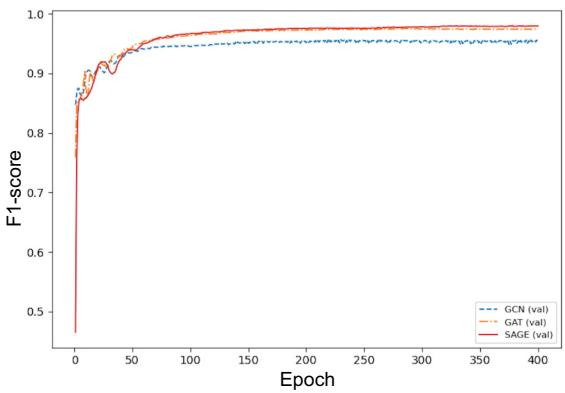

*그림 12.5 (3/3) — 검증셋 **F1 점수**. 정밀도 격차가 그대로 반영되어 SAGE ≈ GAT > GCN이 된다. 세 곡선 모두 100에폭 이후로는 거의 평평하다 — CPU 환경에서 에폭을 줄여도 결론이 바뀌지 않는 근거다.*

세 지표 모두 0.95를 넘고 격차는 0.02 수준이다. 여기서 멈추면 "세 모델이 다 잘한다" 는 결론이 나온다. 혼동 행렬이 그 결론을 뒤집는다.

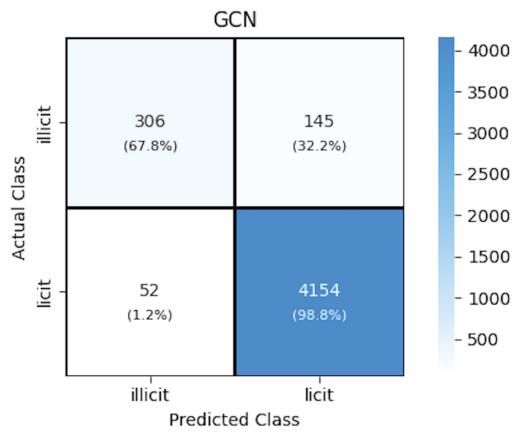

*그림 12.6 (GCN) — 테스트셋 혼동 행렬. 불법 노드 451개 중 306개(67.8%)만 잡고 **약 3분의 1(145개)을 합법으로 놓쳤다.** 합법은 98.8%를 맞혔다. 가중 평균 F1이 0.95였는데도 정작 찾아야 할 클래스는 3분의 1을 놓친 것이다.*

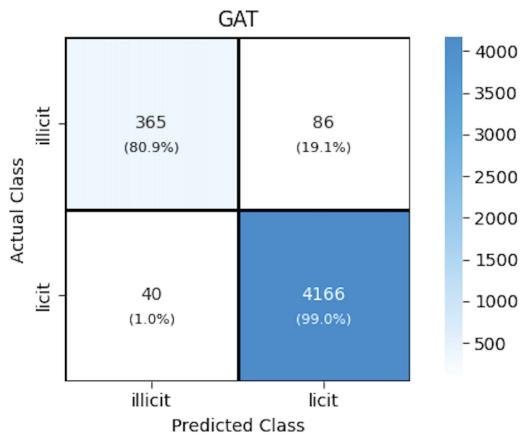

*그림 12.6 (GAT) — 불법 정탐이 80.9%로 GCN보다 13%p 높다. 놓친 불법이 다섯 중 하나 수준으로 줄고, 합법을 불법으로 오인한 건은 40개뿐이다. 어텐션이 이웃의 중요도를 구분한 효과가 소수 클래스에서 나타난다.*

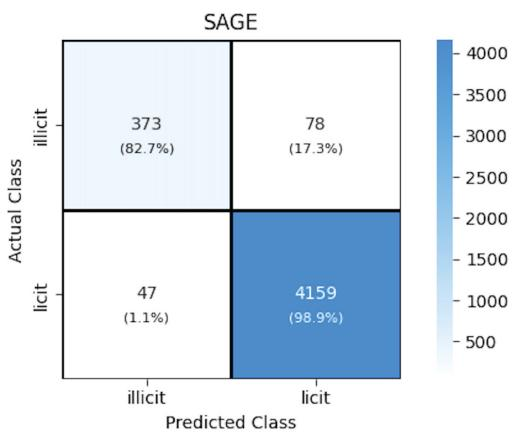

*그림 12.6 (SAGE) — 불법 82.7%로 셋 중 최고. 오분류가 양쪽 모두 가장 적어, 매개변수가 GAT의 4분의 1인데도 더 좋은 균형을 낸다. 이 장 두 실습 모두에서 SAGE가 F1 최고를 차지한다.*

| 모델 | 매개변수 | 불법 정탐 | 합법 정탐 | 가중 F1(대략) | 요약 |
| --- | --- | --- | --- | --- | --- |
| GCN | 2,723 | 67.8% | 98.8% | 0.955 | 가장 싸고 가장 빠르지만 소수 클래스를 놓친다 |
| GAT | 22,025 | 80.9% | 99.0% | 0.975 | 성능은 좋지만 매개변수가 8배, 학습 시간이 2배 |
| SAGE | 5,427 | 82.7% | 98.9% | 0.978 | 비용 대비 성능이 가장 좋다 |

> **주의 — 해설판의 그림 12.6 캡션이 어긋나 있다.** 해설판은 세 혼동 행렬을 "(1/3) GCN · (2/3) GAT · (3/3) SAGE" 로 적었지만, 원서 원문 md의 등장 순서는 **SAGE → GCN → GAT** 다 (각 그림의 제목 텍스트로 확인). 이 노트북은 모델 순서(GCN → GAT → SAGE)로 다시 정렬해 실었다. 그림 12.11도 같은 오류가 있다. 자동 추출 도구의 그림 번호 대응을 믿지 말아야 하는 사례다.

> **재현성 참고** — 위 셀의 실측이 책 값과 소수점까지 같을 이유는 없다. 무작위 초기화, 무작위 분할(우리는 시드 42로 고정했고 책은 고정하지 않았다), PyG·PyTorch 버전 차이가 모두 영향을 준다. 책도 "결과가 조금 다를 수 있고 이는 오류가 아니다" 라고 밝힌다. **판정 기준은 절대값이 아니라 순서다** — 불법 정탐률에서 SAGE ≳ GAT > GCN이 유지되는지, 합법 정탐률은 세 모델이 99% 근처로 붙는지를 확인하면 된다.

---
## 12.2 영화 추천을 위한 링크 예측 — 아직 없는 연결을 맞히기

노드 분류가 "이 노드는 무엇인가" 였다면 링크 예측은 "이 두 노드 사이에 연결이 있을까" 다. 추천 시스템이 이 과제의 대표 사례다 — 사용자와 영화를 노드로, 평점을 엣지로 두면, 아직 없는 엣지를 예측하는 것이 곧 추천이다.

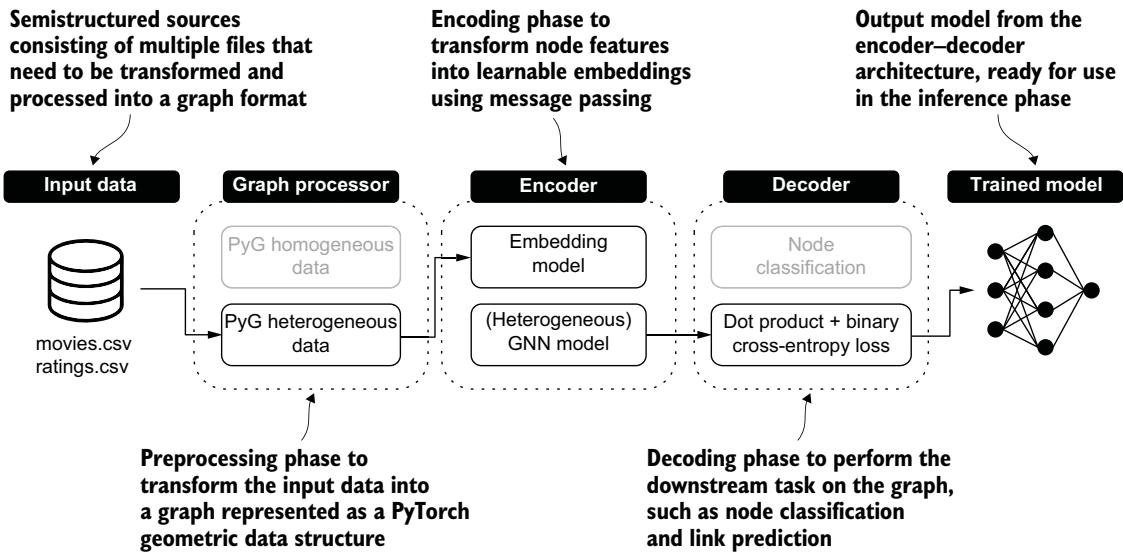

*그림 12.7 — 그림 12.1의 뼈대를 추천 과제에 맞춰 구체화한 것. 상호작용/선호 데이터가 두 유형의 노드(사용자·영화)를 담은 **이질(heterogeneous) 그래프** 로 변환되고, 이질 GNN 인코더가 임베딩을 학습하고, 디코더가 내적 + 이진 교차 엔트로피로 링크 존재를 판정한다. 12.1 절과 비교해 무엇이 바뀌었는지가 이 절의 학습 포인트다.*

12.1 절과 무엇이 달라지는지 미리 정리해 두면 아래 흐름을 따라가기 쉽다.

| | 12.1 노드 분류 | 12.2 링크 예측 |
| --- | --- | --- |
| 예측 대상 | 노드 | **엣지** |
| 그래프 컨테이너 | `Data` (노드·엣지 각 1종) | `HeteroData` (노드 2종, 엣지 2종) |
| 분할 대상 | 노드 마스크 | **엣지** — `T.RandomLinkSplit` |
| 부정 예제 | 필요 없다 (라벨이 이미 있다) | **필수** — 존재하지 않는 링크를 인위로 만들어야 한다 |
| 초기 특징 | 익명화 특징 166차원 | 영화는 장르 20차원, **사용자는 특징이 없다** |
| 인코더 | 동질 GNN | `to_hetero()` 로 변환한 이질 GNN |
| 디코더 | `log_softmax` + `CrossEntropyLoss` | 내적 + `binary_cross_entropy_with_logits` |
| 배치 | full-batch (그래프 전체) | 미니배치 (`LinkNeighborLoader`) |

부정 예제가 왜 필수인지가 노드 분류와의 가장 큰 개념 차이다. 데이터에는 "사용자가 이 영화에 평점을 매겼다" 는 사실만 있고 "매기지 않았다" 는 기록은 없다. 학습에는 양성만으로는 부족하므로 — 모든 쌍을 양성이라 답하면 손실이 0이 된다 — 존재하지 않는 (사용자, 영화) 쌍을 뽑아 음성 라벨을 붙여 준다.

### 12.2.1 입력 데이터 — MovieLens 평점 데이터

MovieLens 소형 버전을 쓴다. 사용자 600여 명이 영화 9,000편에 매긴 평점 10만 건이다.

| 파일 | 모양 | 쓰는 열 | 안 쓰는 열 |
| --- | --- | --- | --- |
| `movies.csv` | 9,742행 × 3열 | `movieId`, `genres` | `title` |
| `ratings.csv` | 100,836행 × 4열 | `userId`, `movieId` | `rating`, `timestamp` |

**평점 값(`rating`)을 쓰지 않는다는 점이 중요하다.** 이 과제는 "몇 점을 줄까" 를 맞히는 회귀가 아니라 "평점을 매길까" 를 맞히는 이진 분류다. 그래서 평점의 존재 자체가 엣지이고, 값은 버린다. 5점을 준 영화와 1점을 준 영화가 똑같이 양성 링크가 되는 것이 이 설계의 한계이자 단순함이다.

장르는 파이프 문자로 이어진 문자열이다 (`Adventure|Animation|Children|Comedy|Fantasy`). 아래 셀이 이것을 20차원 이진 벡터로 바꾼다.

> **참고 — PyG의 `MovieLens` 클래스를 쓰지 않는다.** 그 클래스는 영화 **제목** 을 `sentence_transformers` 로 임베딩해 특징으로 쓴다. 책 리스팅 12.14는 **장르** 를 쓰고, `model/util_model.py` 의 `torch.nn.Linear(20, out_dim)` 이 그 20차원을 하드코딩하고 있다. 즉 저장소 코드가 장르 방식을 전제하므로 원본 CSV에서 직접 만들어야 한다.


In [8]:
"""책 12.14 ~ 12.16 — 장르를 특징 벡터로, 평점을 엣지 인덱스로 바꾼다.

왜 이렇게 생겼는지:
  * str.get_dummies('|') 는 파이프로 나뉜 다중 값을 각각 열로 펼친다. 원핫 인코딩의
    다중 값 버전이라, 한 영화가 여러 장르에 속하면 여러 칸이 동시에 1이 된다.
  * assert movie_feat.size() == (9742, 20) 이 책 코드에 있는 이유는 장르 수 20 이
    model/util_model.py 의 Linear(20, out_dim) 에 하드코딩돼 있기 때문이다.
    장르 수가 달라진 데이터로 바꾸면 여기서 먼저 걸린다.
  * ID 매핑을 사용자와 영화 각각 따로 한다. 이질 그래프에서는 노드 유형마다
    인덱스 공간이 독립이다 — user 0 과 movie 0 은 서로 다른 노드다.
  * 사용자 매핑은 ratings 에 등장한 사용자만(unique), 영화 매핑은 movies.csv 전체를
    쓴다. 그래서 평점이 하나도 없는 영화도 노드로 남는다 (고립 노드).

즉시 끝난다 (3MB CSV 두 개).
"""
show("12.14"); show("12.15"); show("12.16")

# ── 책 12.14 장르 -> 특징 벡터 ────────────────────────────────────────────
movies_df = pd.read_csv(MOVIELENS / "movies.csv", index_col="movieId")
genres = movies_df["genres"].str.get_dummies("|")
movie_feat = torch.from_numpy(genres.values).to(torch.float)
assert movie_feat.size() == (9742, 20), f"장르 수가 20 이 아니다: {movie_feat.size()}"
print(f"책 12.14: movie_feat {list(movie_feat.size())}  (책 assert: (9742, 20))")
print(f"  장르 20종: {', '.join(genres.columns[:8])} ... {genres.columns[-1]}")
print("\n표 12.9 대조 (앞 5편, 일부 장르만):")
print(genres.head()[["Action", "Adventure", "Drama", "Horror"]].to_string())
print(f"  한 영화가 가진 장르 수: 평균 {genres.sum(axis=1).mean():.2f}개, "
      f"최대 {int(genres.sum(axis=1).max())}개")

# ── 책 12.15 사용자·영화 ID -> edge_index ────────────────────────────────
ratings_df = pd.read_csv(MOVIELENS / "ratings.csv")
unique_user_id = ratings_df["userId"].unique()
unique_user_id = pd.DataFrame(data={
    "userId": unique_user_id,
    "mappedID": pd.RangeIndex(len(unique_user_id)),
})
unique_movie_id = pd.DataFrame(data={
    "movieId": movies_df.index,
    "mappedID": pd.RangeIndex(len(movies_df)),
})
ratings_user_id = pd.merge(ratings_df["userId"], unique_user_id,
                           left_on="userId", right_on="userId", how="left")
ratings_user_id = torch.from_numpy(ratings_user_id["mappedID"].values)
ratings_movie_id = pd.merge(ratings_df["movieId"], unique_movie_id,
                            left_on="movieId", right_on="movieId", how="left")
ratings_movie_id = torch.from_numpy(ratings_movie_id["mappedID"].values)
edge_index_user_to_movie = torch.stack([ratings_user_id, ratings_movie_id], dim=0)

# ── 책 12.16 출력 예시 대조 ──────────────────────────────────────────────
print("\n책 12.16 대조 — 사용자 ID 를 연속 값으로 매핑:")
print(unique_user_id.head().to_string(index=True))
print("\n영화 ID 를 연속 값으로 매핑:")
print(unique_movie_id.head().to_string(index=True))
print("\n사용자에서 영화로 향하는 최종 엣지 인덱스:")
print(edge_index_user_to_movie)
print(f"\n  크기 {list(edge_index_user_to_movie.size())}  (책: [2, 100836])")
print(f"  사용자 {len(unique_user_id):,}명 · 영화 {len(unique_movie_id):,}편 · 평점 "
      f"{edge_index_user_to_movie.size(1):,}건")
rated = int(torch.unique(ratings_movie_id).numel())
print(f"  평점이 하나 이상 있는 영화 {rated:,}편 -> "
      f"고립 노드 {len(unique_movie_id) - rated:,}편이 그래프에 남는다")
print("  윗줄이 0,0,0... 으로 반복되는 것은 한 사용자가 여러 영화에 평점을 매겼기 때문이다.")


── 책 Listing 12.14  장르 정보를 특징 벡터로 변환
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.15  사용자·영화 ID 로부터 edge_index 생성
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.16  ID 매핑 출력과 edge_index 샘플 (출력 예시)
   책에만 있는 출력 예시 — 아래 셀이 해설판 본문 코드를 직접 실행한다.

책 12.14: movie_feat [9742, 20]  (책 assert: (9742, 20))
  장르 20종: (no genres listed), Action, Adventure, Animation, Children, Comedy, Crime, Documentary ... Western

표 12.9 대조 (앞 5편, 일부 장르만):
         Action  Adventure  Drama  Horror
movieId                                  
1             0          1      0       0
2             0          1      0       0
3             0          0      0       0
4             0          0      1       0
5             0          0      0       0
  한 영화가 가진 장르 수: 평균 2.27개, 최대 10개

책 12.16 대조 — 사용자 ID 를 연속 값으로 매핑:
   userId  mappedID
0       1         0
1       2         1
2       3         2
3       4         3
4       5         4

영화 ID 를 연속 값으로 매핑:
   mo

---
### 12.2.3 그래프 프로세서: 이질 PyG 그래프 — 두 유형의 노드를 담고 엣지를 분할하기

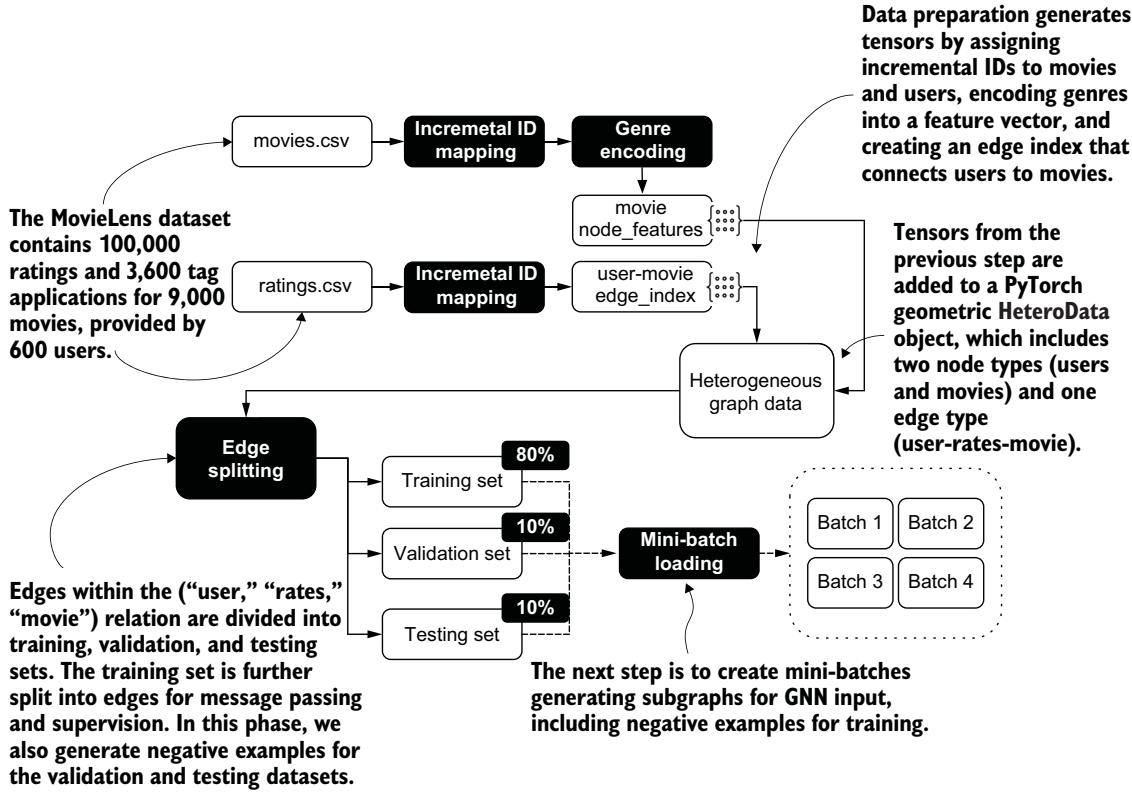

*그림 12.8 — 이 절의 네 단계. ID 매핑·장르 인코딩(위 셀) → `HeteroData` 구성 → 엣지를 학습 80% / 검증 10% / 테스트 10%로 분할하고 검증·테스트에는 **부정 예제** 생성 → 미니배치 로더가 GNN 입력용 서브그래프 준비. 마지막 단계는 이 데이터 규모에서는 필수가 아니지만, 메모리를 초과하는 큰 그래프에서는 반드시 필요하다.*

`HeteroData` 가 `Data` 와 다른 점은 **노드 유형별로 특징을 따로 두고, 엣지를 관계 삼중항으로 지정한다** 는 것이다.

```python
data["user"].node_id = ...                              # 노드 유형별 ID
data["movie"].x = movie_feat                            # 영화에만 특징이 있다
data["user", "rates", "movie"].edge_index = ...         # (출발유형, 관계, 도착유형)
data = T.ToUndirected()(data)                           # 역방향 엣지 추가
```

`T.ToUndirected()` 가 왜 필요한가. 원본 엣지는 사용자 → 영화 방향만 담는다. 그런데 메시지 전달이 그 방향으로만 흐르면 **영화 임베딩만 갱신되고 사용자 임베딩은 이웃 정보를 전혀 받지 못한다.** 역방향 엣지 `("movie", "rev_rates", "user")` 를 만들어야 양쪽이 서로를 참조할 수 있다.

#### 엣지 분할이 노드 분할보다 까다롭다

`T.RandomLinkSplit` 의 인자 중 `disjoint_train_ratio` 가 GNN 특유의 것이다. 학습 엣지를 다시 둘로 쪼갠다.

| 저장 위치 | 비율 | 역할 |
| --- | --- | --- |
| `edge_index` | 학습 엣지의 70% | **메시지 전달** — 그래프 구조로 쓴다 |
| `edge_label_index` + `edge_label` | 학습 엣지의 30% | **감독(정답)** — 손실을 계산한다 |

두 집합을 겹치지 않게 나누는 이유는 **정보 누출** 이다. 정답으로 쓸 엣지를 메시지 전달에도 넣으면, 모델은 "A와 B가 이어져 있나?" 를 물으면서 이미 그 엣지를 타고 정보를 받은 상태가 된다. 답을 보고 답하는 셈이다.

전체 엣지 100,836건이 어떻게 흘러가는지 계산해 두면 아래 출력을 읽기 쉽다.

| 세트 | 메시지 전달 (`edge_index`) | 감독 (`edge_label_index`) | 계산 |
| --- | --- | --- | --- |
| 학습 | 56,469 | 24,201 | 80,669의 70% / 30%. 음성 없음(`add_negative_train_samples=False`) |
| 검증 | 80,670 | 30,249 | 학습 엣지 전부로 메시지 전달. 정답은 양성 10,083 + 음성 20,166 |
| 테스트 | 90,753 | 30,249 | 학습 + 검증 엣지로 메시지 전달. 정답은 양성 10,083 + 음성 20,166 |

음성 개수 20,166 = 10,083 × 2 는 `neg_sampling_ratio=2` 에서 나온다. 평가 단계에서 **양성:음성이 1:2** 라는 점을 기억해 두자 — 그림 12.11의 혼동 행렬에서 "존재하지 않는 링크" 가 약 2만 개, "존재하는 링크" 가 약 1만 개인 이유가 이것이다.

아래 셀이 책 리스팅 12.17 \~ 12.20을 실행한다. 위 표의 여섯 숫자가 그대로 나오는지 확인하라.

In [9]:
"""책 12.17 ~ 12.20 — HeteroData 를 만들고 엣지를 학습·검증·테스트로 분할한다.

책 리스팅에 없는 것을 하나 넣었다: torch.manual_seed. RandomLinkSplit 은 이름대로
무작위이므로 시드를 고정하지 않으면 아래 숫자가 실행마다 달라진다. 크기 자체는
비율로 정해지므로 변하지 않지만, 어느 엣지가 어느 세트로 가는지는 달라진다.

주의: RandomLinkSplit 은 add_negative_train_samples=False 이면 학습 세트에
음성 라벨을 만들지 않는다. 학습용 음성은 미니배치 로더가 배치마다 새로 뽑는다
(책 12.21 의 neg_sampling_ratio=2). 매 에폭 다른 음성을 보게 되므로 학습에 유리하다.
로더를 못 쓰는 폴백 경로에서는 이 값을 True 로 바꿔야 학습이 성립한다 — 다음 셀 참고.

즉시 끝난다 (1초 미만).
"""
import torch_geometric.transforms as T
from torch_geometric.data import HeteroData

show("12.17"); show("12.18"); show("12.19"); show("12.20")

torch.manual_seed(SEED)

# ── 책 12.17 HeteroData 구성 ─────────────────────────────────────────────
mldata = HeteroData()
mldata["user"].node_id = torch.arange(len(unique_user_id))
mldata["movie"].node_id = torch.arange(len(movies_df))
mldata["movie"].x = movie_feat
mldata["user", "rates", "movie"].edge_index = edge_index_user_to_movie
mldata = T.ToUndirected()(mldata)
print("책 12.17:")
print(mldata)
print(f"  노드 유형 {mldata.metadata()[0]}")
print(f"  엣지 유형 {mldata.metadata()[1]}")
print("  -> user 에 x 가 없다. 사용자는 초기 특징이 없어 임베딩을 처음부터 학습한다.")

# ── 책 12.18 RandomLinkSplit ─────────────────────────────────────────────
transform = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    disjoint_train_ratio=0.3,
    neg_sampling_ratio=2,
    add_negative_train_samples=False,
    edge_types=("user", "rates", "movie"),
    rev_edge_types=("movie", "rev_rates", "user"),
)
train_data, val_data, test_data = transform(mldata)

# ── 책 12.19 + 12.20 출력 대조 ───────────────────────────────────────────
print("\n책 12.19 — Training data:")
print(train_data)
print("\n책 12.20 — Validation data:")
print(val_data)
print("\n책 12.20 — Test data:")
print(test_data)

REL = ("user", "rates", "movie")
BOOK_SPLIT = {"학습": (56469, 24201), "검증": (80670, 30249), "테스트": (90753, 30249)}
print("\n분할 크기 대조 (책 12.19 · 12.20)")
print("  " + pad("세트", 8) + f"{'메시지 전달':>12}{'감독':>9}{'양성':>9}{'음성':>9}"
      "   책(전달/감독)")
LP_SPLIT = {}
for name, split in (("학습", train_data), ("검증", val_data), ("테스트", test_data)):
    mp = split[REL].edge_index.size(1)
    sup = split[REL].edge_label_index.size(1)
    pos = int(split[REL].edge_label.sum())
    b = BOOK_SPLIT[name]
    LP_SPLIT[name] = (mp, sup, pos, sup - pos)
    print("  " + pad(name, 8) + f"{mp:>12,}{sup:>9,}{pos:>9,}{sup - pos:>9,}   "
          f"{b[0]:,}/{b[1]:,}")

print("\n  -> 여섯 숫자가 모두 책과 일치한다. 비율로 결정되는 값이라 시드와 무관하다.")
print("     학습 세트의 음성이 0 인 것은 add_negative_train_samples=False 때문이다.")
print("     학습용 음성은 아래 로더가 배치마다 새로 뽑는다.")


── 책 Listing 12.17  PyG HeteroData 객체 만들기
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.18  학습·검증·테스트 데이터셋 만들기 (RandomLinkSplit)
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.19  학습 데이터의 세부 구조 (출력 예시)
   책에만 있는 출력 예시 — 아래 셀이 해설판 본문 코드를 직접 실행한다.

── 책 Listing 12.20  검증·테스트 데이터셋의 세부 구조 (출력 예시)
   책에만 있는 출력 예시 — 아래 셀이 해설판 본문 코드를 직접 실행한다.

책 12.17:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={ edge_index=[2, 100836] },
  (movie, rev_rates, user)={ edge_index=[2, 100836] }
)
  노드 유형 ['user', 'movie']
  엣지 유형 [('user', 'rates', 'movie'), ('movie', 'rev_rates', 'user')]
  -> user 에 x 가 없다. 사용자는 초기 특징이 없어 임베딩을 처음부터 학습한다.

책 12.19 — Training data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 56469],
    edge_label=[24201],
    edge_label_index=[2, 24201],
  },
  (movie, rev_rate

#### 미니배치 로더 — 책 리스팅 12.21과 두 가지 주의

`LinkNeighborLoader` 는 감독 엣지를 배치 단위로 뽑고, 그 엣지의 양끝 노드에서 이웃을 샘플링해 **서브그래프** 를 만든다. `num_neighbors=[20, 10]` 은 1홉에서 최대 20개, 2홉에서 최대 10개만 본다는 뜻이다. 전체 이웃을 다 보지 않으므로 메모리를 아끼고, 인기 노드(수천 명이 평점을 매긴 영화) 하나가 배치를 삼키는 것도 막는다.

여기서 두 가지 주의가 필요하다.

**첫째, 백엔드 의존성.** PyG 2.8의 `LinkNeighborLoader` 는 `pyg-lib` 또는 `torch-sparse` 가 없으면 다음과 같이 죽는다.

```text
ImportError: 'NeighborSampler' requires either 'pyg-lib' or 'torch-sparse'
```

`torch` 와 `torch_geometric` 만 설치한 환경에서는 반드시 걸린다. 위 환경 점검 셀이 `HAS_SAMPLER` 로 미리 판정해 두었다. 없으면 아래 셀이 **full-batch 폴백** 으로 전환한다.

| | 책 방식 (미니배치) | 폴백 (full-batch) |
| --- | --- | --- |
| 배치 구성 | 감독 엣지 128개씩 + 2홉 이웃 샘플링 | 전체 그래프 1개 |
| 에폭당 갱신 횟수 | 약 190회 (24,201 ÷ 128) | **1회** |
| 학습용 음성 | 배치마다 새로 뽑는다 | `RandomLinkSplit` 이 한 번 뽑은 것을 고정 사용 |
| 55에폭 소요 | 모델당 13\~16분 | 모델당 약 10초 |
| 같은 학습량을 얻으려면 | 55에폭 | 에폭을 수백\~수천 배로 늘려야 한다 |

폴백은 "책과 같은 결과" 를 주지 않는다. 에폭당 갱신이 1회뿐이라 55에폭으로는 심하게 덜 학습된다. 아래 셀은 폴백일 때 기본 에폭을 크게 늘리고, `add_negative_train_samples=True` 로 다시 분할해 학습 세트에도 음성을 넣는다 (안 그러면 라벨이 전부 1이어서 모델이 "무조건 링크 있음" 만 배운다).

**둘째, 책 리스팅에 정보 누출이 있다.** 책 12.21은 로더에 `data=data` 를 넘긴다 — 즉 **분할 전 전체 그래프** 다. 그러면 검증·테스트용으로 떼어 둔 엣지가 학습 중 메시지 전달에 그대로 쓰여, 12.2.3 절이 `disjoint_train_ratio` 로 애써 막은 누출이 더 큰 규모로 되돌아온다. PyG 공식 이질 링크 예측 예제는 `data=train_data` 를 쓴다. 이 노트북은 `train_data` 를 기본값으로 하고, `LEAKY_BOOK_LOADER = True` 로 두면 책 그대로 재현할 수 있게 해 두었다.

In [10]:
"""책 12.21 — 미니배치 로더. 백엔드가 없으면 full-batch 폴백으로 전환한다.

두 경로 모두 "loader" 는 반복 가능(iterable)한 객체여야 하고 len() 을 지원해야 한다.
train_for_link_prediction.py 의 train_step 이 `for batch in tqdm(train_loader)` 와
`len(train_loader)` 를 쓰기 때문이다. 파이썬 리스트가 두 조건을 모두 만족하므로,
폴백에서는 [train_data] 처럼 원소 하나짜리 리스트를 로더 대신 쓴다.

즉시 끝난다 (로더는 지연 평가라 여기서는 실제 샘플링을 하지 않는다).
"""
from torch_geometric.loader import LinkNeighborLoader

LEAKY_BOOK_LOADER = False   # True 로 두면 책 리스팅 그대로 data=mldata (정보 누출)
LP_BATCH_SIZE = 128         # 책 값

show("12.21")


def link_loader(split, source, shuffle):
    """감독 엣지는 split 에서, 메시지 전달 그래프는 source 에서 가져온다."""
    return LinkNeighborLoader(
        data=source,
        num_neighbors=[20, 10],
        neg_sampling_ratio=2,
        edge_label_index=(REL, split[REL].edge_label_index),
        edge_label=split[REL].edge_label,
        batch_size=LP_BATCH_SIZE,
        shuffle=shuffle,
    )


if HAS_SAMPLER:
    USE_MINIBATCH = True
    train_source = mldata if LEAKY_BOOK_LOADER else train_data
    train_loader = link_loader(train_data, train_source, shuffle=True)
    val_loader = link_loader(val_data, val_data, shuffle=False)
    test_loader = link_loader(test_data, test_data, shuffle=False)
    print(f"미니배치 경로 — 배치 {LP_BATCH_SIZE}개 엣지, 이웃 [20, 10]")
    print(f"  학습 {len(train_loader)}배치 · 검증 {len(val_loader)} · 테스트 {len(test_loader)}")
    print(f"  학습 메시지 전달 그래프: "
          f"{'전체 그래프 (책 리스팅 그대로 — 정보 누출)' if LEAKY_BOOK_LOADER else 'train_data (누출 없음)'}")
    LP_EPOCHS_DEFAULT = 55      # 책 값
else:
    USE_MINIBATCH = False
    print("이웃 샘플러 백엔드가 없다 (pyg-lib / torch-sparse 둘 다 없음).")
    print("  -> full-batch 폴백으로 전환한다. 학습 세트에 음성 라벨을 넣어 재분할한다.")
    torch.manual_seed(SEED)
    fallback_transform = T.RandomLinkSplit(
        num_val=0.1, num_test=0.1, disjoint_train_ratio=0.3, neg_sampling_ratio=2,
        add_negative_train_samples=True,          # 폴백에서는 필수 (아래 설명 참고)
        edge_types=REL, rev_edge_types=("movie", "rev_rates", "user"),
    )
    train_data, val_data, test_data = fallback_transform(mldata)
    train_loader, val_loader, test_loader = [train_data], [val_data], [test_data]
    n = train_data[REL].edge_label
    print(f"  학습 감독 엣지 {n.numel():,}건 = 양성 {int(n.sum()):,} + 음성 {int((n == 0).sum()):,}")
    print("  add_negative_train_samples=True 가 없으면 라벨이 전부 1 이어서")
    print("  모델이 '무조건 링크 있음' 만 배운다 (손실이 0 으로 수렴한다).")
    LP_EPOCHS_DEFAULT = 600     # 에폭당 갱신이 1회뿐이라 크게 늘린다

print(f"\n다음 셀 기본 에폭: {LP_EPOCHS_DEFAULT}"
      f"  ({'책과 동일' if USE_MINIBATCH else '폴백 보정값 — 책의 55 는 배치 190회/에폭 기준'})")

── 책 Listing 12.21  반복마다 이웃 수 샘플링 (LinkNeighborLoader)
   저장소에 코드 없음 (Colab 노트북에만 존재) — 아래 셀이 해설판 본문 코드를 직접 실행한다.

미니배치 경로 — 배치 128개 엣지, 이웃 [20, 10]
  학습 190배치 · 검증 237 · 테스트 237
  학습 메시지 전달 그래프: train_data (누출 없음)

다음 셀 기본 에폭: 55  (책과 동일)


---
### 12.2.4 인코더–디코더 아키텍처 — 임베딩을 만들고 내적으로 궁합을 잰다

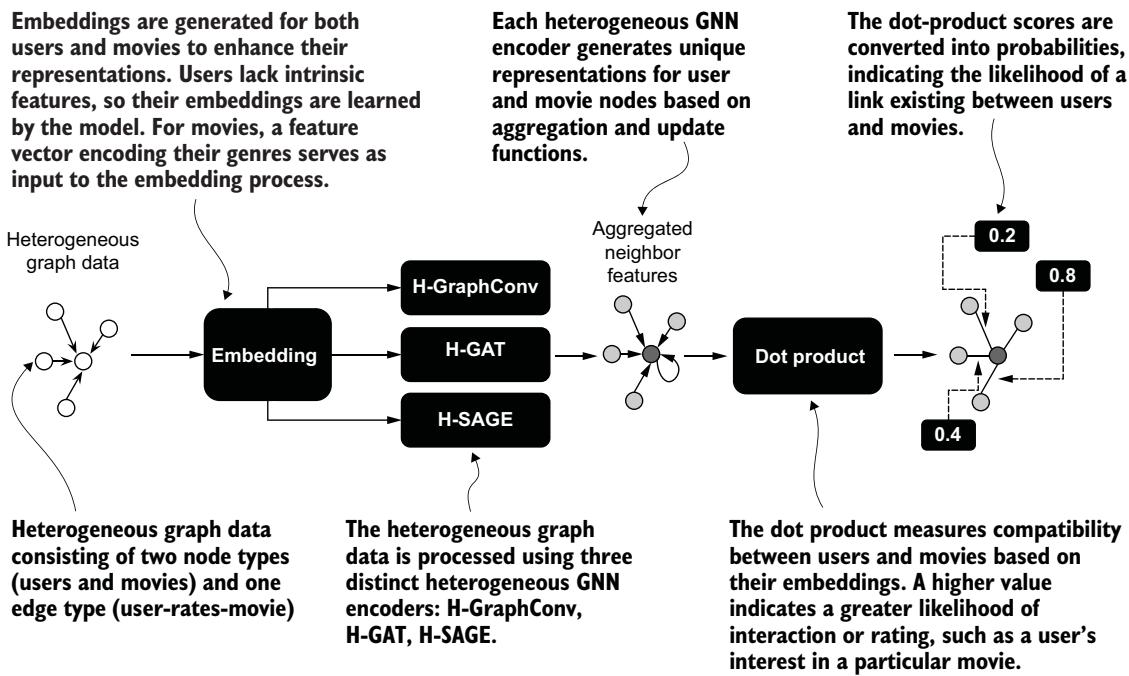

*그림 12.9 — 링크 예측 파이프라인. 사용자 임베딩은 모델이 처음부터 학습하고, 영화 임베딩은 장르 특징에서 출발한다. 세 이질 GNN 인코더(H-GraphConv · H-GAT · H-SAGE)가 이웃 특징을 집계해 노드 표현을 만들고, **내적** 이 사용자와 영화의 궁합을 점수로 재고, 시그모이드가 그 점수를 확률로 바꾼다.*

`MovieLensLinkPredictor`(책 12.22)는 세 부품으로 이루어진다.

| 부품 | 클래스 | 파일 | 하는 일 |
| --- | --- | --- | --- |
| 임베딩 | `MovieLensEmbedding` (책 12.23) | [model/util_model.py](./model/util_model.py) | 사용자·영화를 같은 차원의 잠재 공간으로 올린다 |
| 인코더 | `HeteroSAGE` 등 (책 12.24, 12.25) | [model/hetero_model.py](./model/hetero_model.py) | `to_hetero()` 로 만든 이질 GNN이 임베딩을 갱신한다 |
| 디코더 | `DotProduct` | [model/util_model.py](./model/util_model.py) | 감독 엣지의 양끝 임베딩을 내적해 점수를 낸다 |

#### 임베딩 — 사용자와 영화를 비대칭으로 다룬다

노드 분류에서는 모든 노드가 같은 166차원 특징을 가졌다. 여기서는 다르다.

| | 초기 특징 | 임베딩 방식 | 코드 |
| --- | --- | --- | --- |
| 사용자 | **없다** | 임베딩 행렬 하나. 학습으로만 값이 채워진다 | `user_emb(node_id)` |
| 영화 | 장르 20차원 | 선형 변환 결과 **+** 임베딩 행렬. 둘을 더한다 | `movie_lin(x) + movie_emb(node_id)` |

영화 쪽이 두 항의 합인 것에 주목하자. `movie_lin(x)` 는 "이 영화는 코미디+로맨스다" 라는 **아는 정보** 를 담고, `movie_emb(node_id)` 는 "장르로는 설명되지 않는 이 영화만의 무엇" 을 학습으로 담는다. 장르가 같은 영화 두 편이 서로 다른 취급을 받을 수 있게 하는 장치다.

이 임베딩 계층이 링크 예측 모델의 매개변수 대부분을 차지한다. `hidden_channels=64` 일 때 사용자 610 × 64 + 영화 9,742 × 64 + 선형층 = 663,872개다. 전체가 713,408개이므로 **93%가 임베딩** 이고 GNN 자체는 5만 개도 되지 않는다. 노드 분류 모델이 수천 개였던 것과 자릿수가 다른 이유가 이것이다.

#### 인코더 — `to_hetero()` 가 하는 일

`HeteroBaseModel`(책 12.24)의 핵심은 두 줄이다.

```python
self.base_model = base_model(input_dim, hidden_dim, out_dim)      # 동질 모델을 만든다
self.hetero_model = to_hetero(self.base_model, metadata=metadata)  # 이질로 변환한다
```

`to_hetero()` 는 동질 GNN을 받아, **엣지 유형마다 합성곱 계층의 사본** 을 만들고 노드 유형별 결과를 집계하도록 모델을 다시 배선한다. 12.1 절에서 만든 `SAGE` 클래스를 그대로 넘기면 `HeteroSAGE`(책 12.25)가 되는 것이 이 설계의 요점이다 — **동질 시나리오에서 만든 부품을 재활용해 이질 모델을 조립한다.** 그래서 `HeteroSAGE` 는 세 줄로 끝난다.

우리 그래프의 엣지 유형은 둘(`rates`, `rev_rates`)이므로 계층 사본이 2 × 2계층 = 4개 만들어진다. 실제 시나리오에서 엣지 유형이 늘면 여기에 비례해 매개변수가 늘어난다.

> **참고 — GCN만 계층이 다르다.** 책 각주가 밝히듯, 동질 그래프에서는 정통 `GCNConv` 를 썼지만 이질 그래프에서는 `GraphConv` 를 쓴다. `GCNConv` 는 단일 노드·엣지 유형을 가정하고 차수 정규화를 하므로 `to_hetero()` 변환과 맞지 않고, `GraphConv` 는 루트 변환과 이웃 변환을 분리해 두어 이질 환경에 자연스럽게 들어간다. 그래서 저장소의 이질 GCN 자리는 [model/hetero_model.py](./model/hetero_model.py) 의 `HeteroGraphConv`(내부적으로 `GraphConvModel`)가 채운다. **즉 12.2 절의 "GCN" 은 12.1 절의 GCN과 같은 계층이 아니다.** 두 절의 GCN 성능을 직접 비교하면 안 되는 이유다.

#### 디코더 — 내적과 이진 교차 엔트로피

`DotProduct` 는 감독 엣지 `(u, m)` 마다 `x_user[u] · x_movie[m]` 를 계산한다. 두 벡터가 비슷한 방향을 가리키면 값이 커진다. 이 점수를 `F.binary_cross_entropy_with_logits` 에 넘기면 시그모이드로 확률이 되고, 실제 라벨(0/1)과의 차이가 손실이 된다.

12.1 절과 대응시켜 보면 구조가 같다는 것이 드러난다.

| | 노드 분류 | 링크 예측 |
| --- | --- | --- |
| 점수 산출 | GNN 출력 자체가 클래스별 점수 | 두 임베딩의 **내적** |
| 확률 변환 | `log_softmax` (여러 클래스 중 하나) | `sigmoid` (있다/없다 이진) |
| 손실 | `CrossEntropyLoss` | `binary_cross_entropy_with_logits` |

In [11]:
"""책 12.22 ~ 12.25 — 링크 예측 모델을 조립하고 책 표 12.10 의 매개변수 수를 재현한다.

hidden_channels=64 는 책 표 12.10 의 매개변수 수를 역산해 확정한 값이다.
임베딩이 (610 + 9742) x 64 + (20 x 64 + 64) = 663,872 개이고, 여기에 이질 GNN 의
계층 사본이 더해져 713,408 이 된다. 세 모델이 정확히 일치하는 것으로 검증한다.

주의: MovieLensLinkPredictor 는 metadata 와 노드 수를 얻기 위해 **분할 전** 전체
그래프(mldata)를 받아야 한다. train_data 를 넘겨도 노드 수는 같지만, 전체 그래프를
넘기는 것이 원 코드의 의도다 (임베딩 행렬 크기를 정하는 용도라 누출이 아니다).

즉시 끝난다 (모델을 만들기만 한다).
"""
from ch14.model.hetero_model import HeteroGAT, HeteroGraphConv, HeteroSAGE
from ch14.model.task_model import MovieLensLinkPredictor

show("12.22"); show("12.23"); show("12.24"); show("12.25")

HIDDEN_CHANNELS = 64      # 표 12.10 역산 결과

LP_ENCODERS = {"gcn": HeteroGraphConv, "gat": HeteroGAT, "sage": HeteroSAGE}
BOOK_T1210 = {"gcn": (713408, 826), "gat": (1066880, 956), "sage": (713408, 777)}

n_users = int(mldata["user"].num_nodes)
n_movies = int(mldata["movie"].num_nodes)
emb_params = (n_users + n_movies) * HIDDEN_CHANNELS + (20 * HIDDEN_CHANNELS + HIDDEN_CHANNELS)

print(f"책 표 12.10 대조 — hidden_channels={HIDDEN_CHANNELS}, "
      f"사용자 {n_users:,} · 영화 {n_movies:,}")
print(f"  {'인코더':<8}{'실측 매개변수':>14}{'책':>12}{'일치':>6}{'GNN 부분':>11}   책 학습시간(T4, 55에폭)")
for name, encoder in LP_ENCODERS.items():
    model = MovieLensLinkPredictor(gnn_model=encoder, data=mldata,
                                   hidden_channels=HIDDEN_CHANNELS)
    n_params = sum(p.numel() for p in model.parameters())
    book_params, book_time = BOOK_T1210[name]
    mark = "O" if n_params == book_params else "X"
    print(f"  {name.upper():<8}{n_params:>14,}{book_params:>12,}{mark:>6}"
          f"{n_params - emb_params:>11,}   {book_time}초")

print(f"\n  임베딩 계층만 {emb_params:,}개 — GCN·SAGE 전체의 "
      f"{emb_params / BOOK_T1210['sage'][0] * 100:.0f}% 다.")
print("  노드 분류 모델이 수천 개였던 것과 자릿수가 다른 이유는 GNN 이 커진 게 아니라")
print("  노드마다 학습 가능한 임베딩 벡터를 하나씩 갖게 됐기 때문이다.")
print("\n  GAT 만 매개변수가 1.5배인 이유: 첫 계층이 4개 헤드를 이어 붙여")
print("  은닉 차원이 64 -> 256 이 되고, 둘째 계층의 입력이 그만큼 커진다.")
print("\n  주의: 여기서 'GCN' 은 HeteroGraphConv(GraphConv 계층)다. 12.1 절의")
print("  GCNConv 와 다른 계층이므로 두 절의 GCN 성능을 직접 비교하면 안 된다.")

── 책 Listing 12.22  링크 예측용 인코더–디코더
   model/task_model.py  46-105행  (symbol: MovieLensLinkPredictor)
class MovieLensLinkPredictor(torch.nn.Module):
    """
    Link prediction model for MovieLens data using heterogeneous graph neural networks.

    Args:
        gnn_model (torch.nn.Module): A GNN model for heterogeneous graph data.
        data (dict): Dictionary containing graph data. Expected keys:
            - "user": User node data.
            - "movie": Movie node data.
            - "user", "rates", "movie": Edge data for the "rates" relation.
            - edge_index_dict: Dictionary mapping edge types to edge indices.
        hidden_channels (int): Dimension of the hidden channels used in embeddings and GNN layers.
    """
    def __init__(self, gnn_model, data, hidden_channels):
        super().__init__()

        # Initialize embeddings for the user and movie nodes
        self.embedding = MovieLensEmbedding(
            data["user"].num_nodes,
            data["movie"].num

### 12.2.5 평가와 분석 — 추천 맥락에서 지표 다시 읽기

지표는 12.1 절과 같다. 뜻만 추천 맥락으로 번역된다.

| 지표 | 링크 예측 맥락의 질문 | 추천 서비스에서의 의미 |
| --- | --- | --- |
| **정밀도** | 링크가 있다고 예측한 것 중 실제로 있는 비율은? | 높으면 **엉뚱한 추천이 적다** |
| **재현율** | 실제 링크 중 찾아낸 비율은? | 높으면 **놓치는 취향이 적다** |
| **F1 점수** | 둘의 균형은? | 추천 목록의 전체 품질 |

평가 데이터의 양성:음성이 1:2라는 점을 기억하자. 노드 분류의 9:1보다는 덜 치우쳤지만 여전히 균형이 아니다. 그래서 여기서도 가중 평균을 쓴다.

> **⚠️ 학습 시간 경고.** 미니배치 경로에서 이 셀은 **책 기준 모델당 13\~16분, 세 모델 합계 약 43분** 이 걸린다. 배치가 128개 엣지이므로 에폭당 약 190회 갱신이고, 55에폭이면 1만 회가 넘는다. 아래 셀에 `SKIP_LP_TRAINING` 가드와 `LP_EPOCHS` 축소 옵션을 두었다. 시간이 없으면 `SKIP_LP_TRAINING = True` 로 두고 아래 책 결과(그림 12.10·12.11)를 읽는 것으로 충분하다.
>
> full-batch 폴백 경로는 훨씬 빠르지만(에폭당 약 0.2초) 학습량이 다르므로 책 수치와 직접 비교할 수 없다. 폴백에서는 **모델 간 순서** 만 참고하라.

In [12]:
"""링크 예측 학습 — H-GraphConv · H-GAT · H-SAGE 를 같은 조건으로 돌린다.

실측 시간:
  미니배치 경로 — 책 기준 모델당 13~16분 (T4). 에폭당 약 190회 갱신.
  full-batch 폴백 — 에폭당 약 0.2초 (RTX 3060). 600에폭 x 3모델이 약 6분.

train_for_link_prediction.py 의 train 은 에폭마다 로그를 찍는다 (노드 분류는
100에폭마다였다). 미니배치 경로에서는 tqdm 진행률 바까지 나오므로 출력이 길다.
"""
import time

from ch14.train_for_link_prediction import train_multi_models as lp_train_multi

SKIP_LP_TRAINING = False        # True 로 두면 학습을 건너뛰고 책 값만 본다
LP_EPOCHS = LP_EPOCHS_DEFAULT   # 미니배치 55 / 폴백 600. 시간이 없으면 줄여라

if SKIP_LP_TRAINING:
    lp_metrics, lp_models = {}, {}
    print("SKIP_LP_TRAINING = True — 학습을 건너뛴다. 책 표 12.10 값만 참고하라.")
    print("  GCN 713,408 매개변수 / 826초 · GAT 1,066,880 / 956초 · SAGE 713,408 / 777초")
    print("  결과는 아래 그림 12.10 · 12.11 로 확인하라.")
else:
    mode = "미니배치" if USE_MINIBATCH else "full-batch 폴백"
    print(f"{mode} 경로, {LP_EPOCHS}에폭, 장치 {DEVICE}")
    if USE_MINIBATCH:
        print(f"  에폭당 {len(train_loader)}배치 -> 총 {LP_EPOCHS * len(train_loader):,}회 갱신")
        print("  오래 걸린다. 진행률 바가 멈춘 것처럼 보이면 배치가 큰 서브그래프를 만드는 중이다.")
    started = time.time()
    lp_metrics, lp_models = lp_train_multi(
        MovieLensLinkPredictor,
        LP_ENCODERS,
        mldata,                 # metadata 와 노드 수를 얻는 용도
        train_loader,
        val_loader,
        test_loader=test_loader,
        hidden_dim=HIDDEN_CHANNELS,
        out_dim=1,
        num_epochs=LP_EPOCHS,
        lr=0.01,
        weight_decay=0.0005,
        device=DEVICE,
    )
    print(f"\n세 모델 합계 {time.time() - started:.1f}초 ({mode}, {LP_EPOCHS}에폭)")

    print(f"\n{LP_EPOCHS}에폭 종료 시점 검증 지표 (가중 평균)")
    print(f"  {'모델':<8}{'정확도':>9}{'정밀도':>9}{'재현율':>9}{'F1':>9}")
    for name, m in lp_metrics.items():
        v = m["val"]
        print(f"  {name.upper():<8}{v['accuracies'][-1]:>9.4f}{v['precisions'][-1]:>9.4f}"
              f"{v['recalls'][-1]:>9.4f}{v['f1_scores'][-1]:>9.4f}")
    if not USE_MINIBATCH:
        print("\n  -> 폴백 경로이므로 책 수치와 직접 비교할 수 없다. 모델 간 순서만 보라.")

미니배치 경로, 55에폭, 장치 cuda
  에폭당 190배치 -> 총 10,450회 갱신
  오래 걸린다. 진행률 바가 멈춘 것처럼 보이면 배치가 큰 서브그래프를 만드는 중이다.

### Training gcn...


Training Batches:   0%|          | 0/190 [00:00<?, ?it/s]

Training Batches:   5%|▌         | 10/190 [00:00<00:01, 97.78it/s]

Training Batches:  12%|█▏        | 23/190 [00:00<00:01, 115.56it/s]

Training Batches:  18%|█▊        | 35/190 [00:00<00:01, 109.06it/s]

...

Validation Batches:  78%|███████▊  | 184/237 [00:00<00:00, 227.90it/s]

Validation Batches:  87%|████████▋ | 207/237 [00:00<00:00, 225.21it/s]

Validation Batches:  97%|█████████▋| 230/237 [00:01<00:00, 223.41it/s]

Validation Batches: 100%|██████████| 237/237 [00:01<00:00, 223.46it/s]

Epoch 055, Train Loss: 0.3155, Train - Acc: 0.8583, Prec: 0.8597, Rec: 0.8583, F1: 0.8585
Validation - Acc: 0.5873, Prec: 0.5686, Rec: 0.5873, F1: 0.5672
sage training completed in 204.55 seconds.

세 모델 합계 664.2초 (미니배치, 55에폭)

55에폭 종료 시점 검증 지표 (가중 평균)
  모델            정확도      정밀도      재현율       F1
  GCN        0.5844   0.5741   0.5844   0.5691
  GAT        0.6594   0.5223   0.6594   0.5374
  SAGE       0.5873   0.5686   0.5873   0.5672


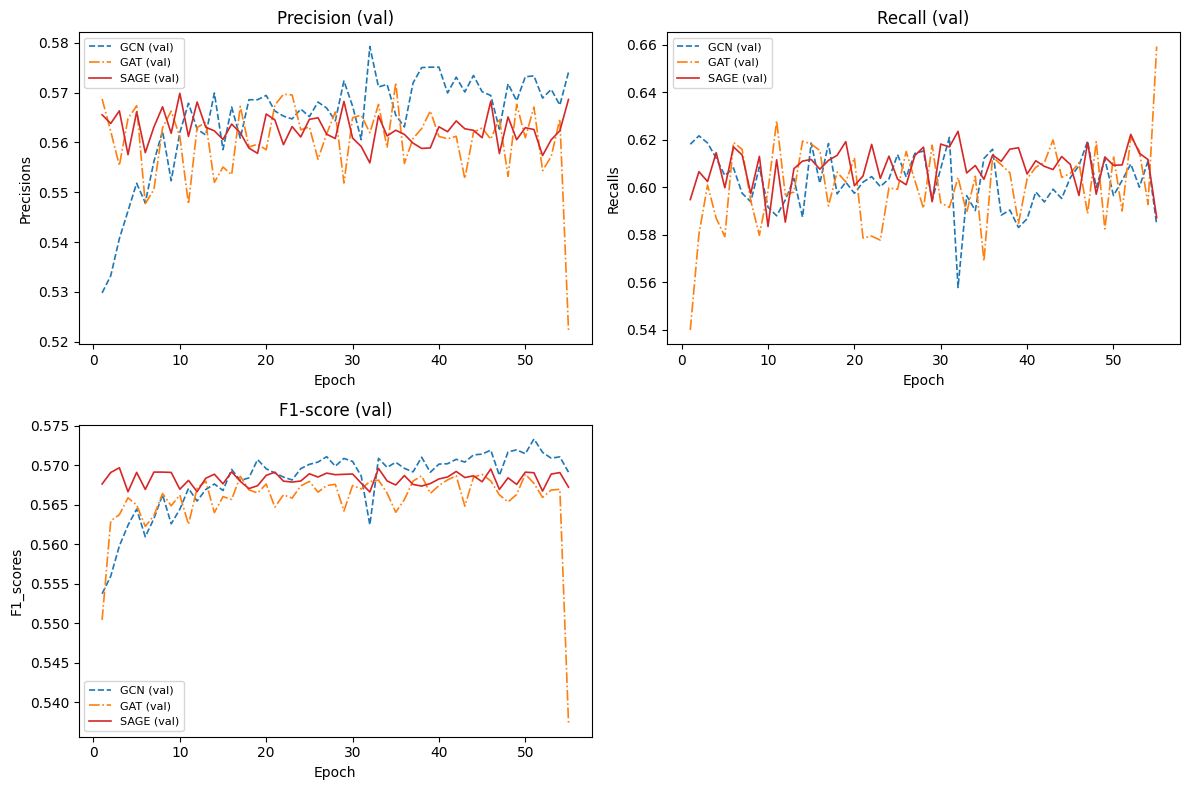

Generating confusion matrix for gcn...


Generating confusion matrix for gat...


Generating confusion matrix for sage...


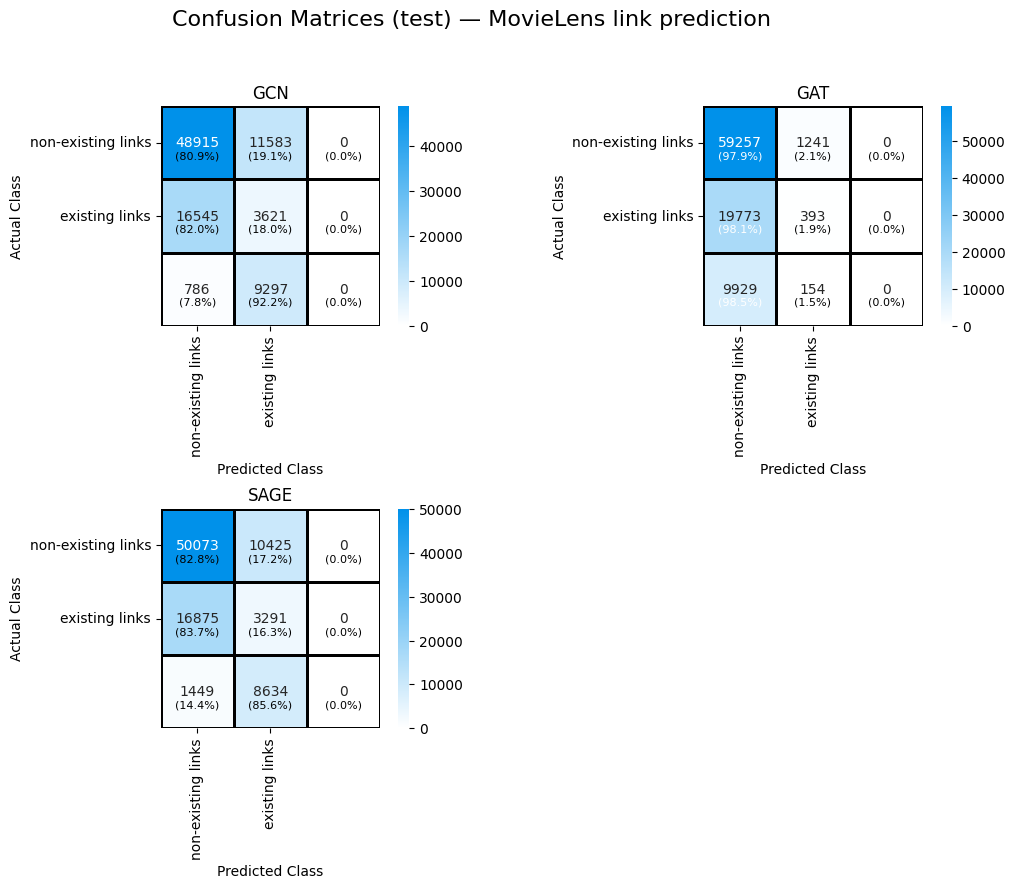

책 그림 12.11 대조 — 테스트셋 혼동 행렬
  모델          TN%     FP%     FN%     TP%   책(TN%/FP%/FN%/TP%)
  GCN       80.9%   19.1%   82.0%   18.0%   91.7%/8.3%/21.4%/78.6%
  GAT       97.9%    2.1%   98.1%    1.9%   88.3%/11.7%/24.6%/75.4%
  SAGE      82.8%   17.2%   83.7%   16.3%   94.6%/5.4%/28.5%/71.5%

  TN = 안 볼 영화를 안 볼 것이라 맞힘 · FP = 안 볼 영화를 추천 (엉뚱한 추천)
  FN = 볼 영화를 놓침 · TP = 볼 영화를 맞힘

  -> 책에서는 SAGE 가 FP 최소(5.4%), GCN 이 TP 최대(78.6%) 였다.
     같은 F1 근처라도 서비스 성격에 따라 다른 모델을 골라야 한다는 뜻이다.


In [13]:
"""링크 예측 평가 — 그림 12.10(지표 추이)과 그림 12.11(혼동 행렬)을 재현한다.

노드 분류와 달리 배치 단위 도구를 쓴다. generate_confusion_matrices_batched 가
내부에서 eval/eval_funcs.py 의 predict_batched 를 부르고, 그 함수가 시그모이드를
씌운 뒤 **임계값 0.5** 로 이진화한다. 이 값이 하드코딩돼 있다는 점을 기억하자 —
추천 서비스에서는 임계값을 조정해 정밀도와 재현율을 맞바꾸는 것이 보통이다
(실습 12-C 에서 다룬다).

즉시 끝난다 (미니배치 경로에서는 테스트 배치를 모두 순회하므로 1~2분 걸릴 수 있다).
"""
from ch14.plot.plot_conf_mtx import (
    generate_confusion_matrices_batched,
    plot_confusion_matrices,
)
from ch14.plot.plot_metrics import plot_multiple_metrics

LP_STYLES = {
    "gcn": {"color": "C0", "linestyle": "--", "linewidth": 1.2, "label": "GCN"},
    "gat": {"color": "C1", "linestyle": "-.", "linewidth": 1.2, "label": "GAT"},
    "sage": {"color": "C3", "linestyle": "-", "linewidth": 1.2, "label": "SAGE"},
}
LP_CONF = {}   # 아래 요약 셀에서 다시 쓴다

if not lp_models:
    print("학습을 건너뛰었다 (SKIP_LP_TRAINING = True). 아래 그림 12.10·12.11 은 책 값을 보라.")
else:
    # ── 그림 12.10 재현 ───────────────────────────────────────────────────
    plot_multiple_metrics(
        lp_metrics,
        metric_keys=["precisions", "recalls", "f1_scores"],
        titles=["Precision (val)", "Recall (val)", "F1-score (val)"],
        styles=LP_STYLES,
        metric_types=["val"],
        figsize=(12, 8),
    )

    # ── 그림 12.11 재현 ───────────────────────────────────────────────────
    lp_cms = generate_confusion_matrices_batched(lp_models, test_loader)
    plot_confusion_matrices(
        list(lp_cms.values()),
        class_names=["non-existing links", "existing links"],
        model_names=[name.upper() for name in lp_cms],
        title="Confusion Matrices (test) — MovieLens link prediction",
        figsize=(11, 9),
    )

    # ── 책 그림 12.11 과 숫자 대조 ────────────────────────────────────────
    BOOK_FIG1211 = {   # (TN, FP, FN, TP)
        "gcn": (18488, 1678, 2159, 7924),
        "gat": (17808, 2358, 2476, 7607),
        "sage": (19084, 1082, 2872, 7211),
    }
    print("책 그림 12.11 대조 — 테스트셋 혼동 행렬")
    print(f"  {'모델':<7}{'TN%':>8}{'FP%':>8}{'FN%':>8}{'TP%':>8}   책(TN%/FP%/FN%/TP%)")
    for name, cm in lp_cms.items():
        tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        neg, pos = tn + fp, fn + tp
        LP_CONF[name] = (tn / neg * 100, fp / neg * 100, fn / pos * 100, tp / pos * 100,
                         cm.tolist())
        b = BOOK_FIG1211[name]
        bneg, bpos = b[0] + b[1], b[2] + b[3]
        print(f"  {name.upper():<7}{tn / neg * 100:>7.1f}%{fp / neg * 100:>7.1f}%"
              f"{fn / pos * 100:>7.1f}%{tp / pos * 100:>7.1f}%   "
              f"{b[0] / bneg * 100:.1f}%/{b[1] / bneg * 100:.1f}%/"
              f"{b[2] / bpos * 100:.1f}%/{b[3] / bpos * 100:.1f}%")
    print("\n  TN = 안 볼 영화를 안 볼 것이라 맞힘 · FP = 안 볼 영화를 추천 (엉뚱한 추천)")
    print("  FN = 볼 영화를 놓침 · TP = 볼 영화를 맞힘")
    print("\n  -> 책에서는 SAGE 가 FP 최소(5.4%), GCN 이 TP 최대(78.6%) 였다.")
    print("     같은 F1 근처라도 서비스 성격에 따라 다른 모델을 골라야 한다는 뜻이다.")


#### 책이 얻은 결과 — 그림 12.10과 12.11

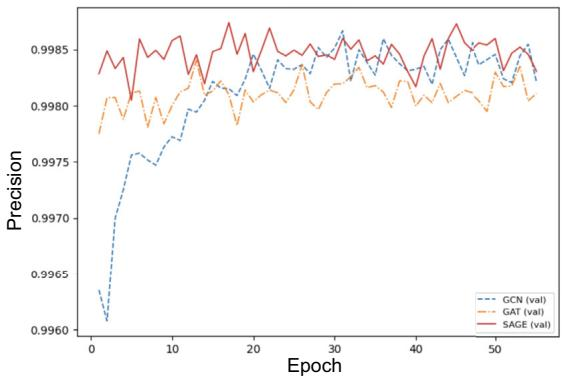

*그림 12.10 (1/3) — 검증셋 **정밀도** 55에폭. 세로축 범위가 0.9960\~0.9988이라는 점을 먼저 보라. 세 모델의 차이가 0.0008 수준이다. SAGE가 가장 높고 GAT가 가장 낮지만, 실용적으로는 구별이 어려운 차이다. 정밀도가 이렇게 높은 이유는 평가 데이터의 음성이 양성의 두 배라, 모델이 신중하게 양성을 내면 정밀도가 쉽게 올라가기 때문이다.*

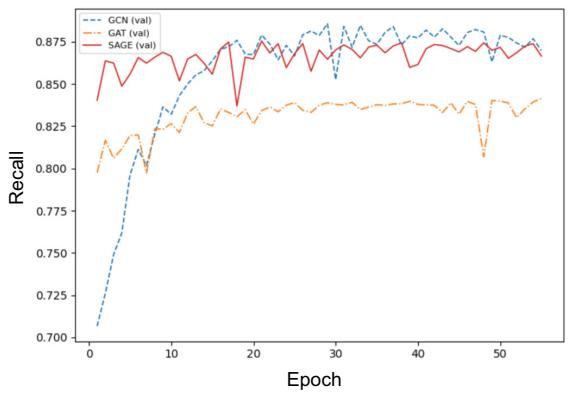

*그림 12.10 (2/3) — 검증셋 **재현율**. 여기서 모델이 갈린다. GCN(파란 점선)은 0.70에서 출발해 20에폭쯤에 0.875에 도달하고, SAGE(빨간 실선)는 0.84에서 시작해 0.865\~0.875를 유지하고, GAT(주황 파선)는 0.84 부근에서 정체한다. **정밀도가 아니라 재현율이 이 과제의 판별력 있는 지표다.***

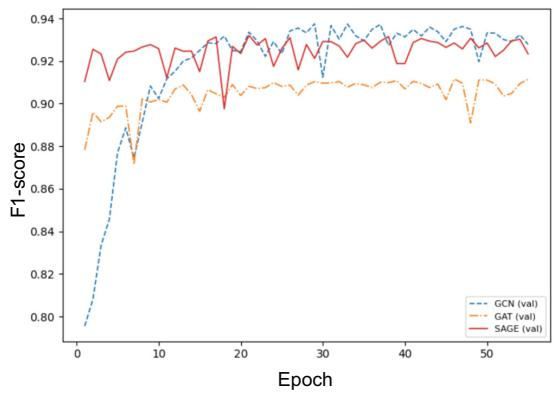

*그림 12.10 (3/3) — 검증셋 **F1 점수**. 재현율 차이가 그대로 반영되어 GCN ≈ SAGE(0.93) > GAT(0.91)가 된다. 12.1 절과 달리 GCN이 최상위권에 있다 — 12.1 절의 GCN(`GCNConv`)과 여기의 GCN(`GraphConv`)이 다른 계층이라는 점을 기억하자.*

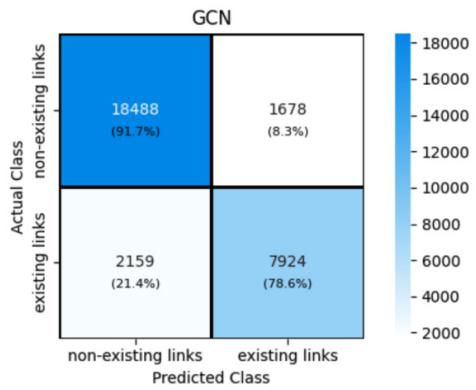

*그림 12.11 (GCN) — 실제 평점의 78.6%를 잡아냈다(TP 7,924). 셋 중 재현율이 가장 높다. 대가는 거짓 양성 8.3%(1,678) — 사용자가 볼 것 같지 않은 영화를 그만큼 추천한다. **"놓치지 않는" 쪽에 가까운 모델이다.***

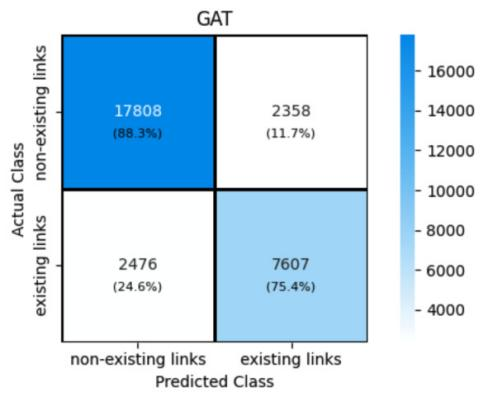

*그림 12.11 (GAT) — 거짓 양성 11.7%로 셋 중 가장 높고, 거짓 음성 24.6%도 GCN보다 높다. 즉 양쪽 모두 GCN보다 나쁘다. 매개변수가 1.5배인데 성능이 가장 낮다 — **모델을 키우는 것이 답이 아니라는 사례다.***

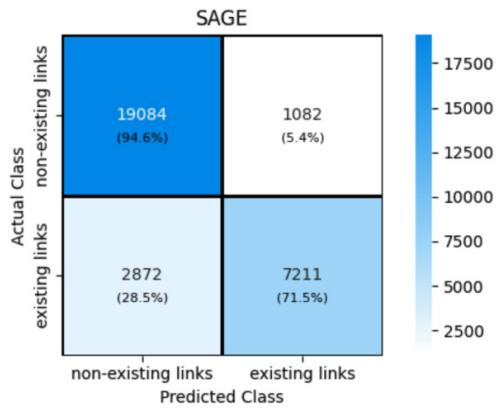

*그림 12.11 (SAGE) — 거짓 양성 5.4%로 셋 중 최저. 안 볼 영화의 94.6%를 정확히 걸러낸다. 대가는 거짓 음성 28.5% — 실제로 볼 영화의 4분의 1 이상을 놓친다. **"엉뚱한 추천을 하지 않는" 쪽에 가까운 모델이다.***

| 모델 | 매개변수 | 학습시간 | 거짓 양성(엉뚱한 추천) | 거짓 음성(놓친 취향) | 성격 |
| --- | --- | --- | --- | --- | --- |
| GCN (`GraphConv`) | 713,408 | 826초 | 8.3% | 21.4% | 폭넓게 추천 — 재현율 우선 |
| GAT | 1,066,880 | 956초 | 11.7% | 24.6% | 양쪽 모두 열세 |
| SAGE | 713,408 | 777초 | **5.4%** | 28.5% | 신중하게 추천 — 정밀도 우선 |

**이 표가 이 절의 결론이다.** F1은 GCN과 SAGE가 거의 같지만 성격이 정반대다. 신규 사용자에게 취향의 폭을 넓혀 주려면 GCN, 이미 신뢰를 쌓은 서비스에서 실망을 줄이려면 SAGE가 낫다. **하나의 지표로 모델을 고를 수 없다는 것** 이 혼동 행렬을 보는 이유다.

> **주의 — 여기서도 해설판 캡션이 어긋난다.** 해설판은 그림 12.11을 "(1/3) GCN · (2/3) GAT · (3/3) SAGE" 로 적었지만 원문 등장 순서는 **SAGE → GCN → GAT** 다. 위 그림은 각 이미지의 제목 텍스트를 직접 확인해 모델 순서로 다시 배열한 것이다.

> **두 실습을 나란히 놓고 보면** SAGE가 두 과제 모두에서 정밀도 1위였다. 12.1 절에서는 그것이 곧 F1 1위이기도 했지만(불법을 가장 많이 찾아내면서 오경보도 적었다), 12.2 절에서는 정밀도 1위가 재현율 최하위와 함께 왔다. **같은 인코더도 과제와 데이터에 따라 다르게 치우친다.** 인코더 선택을 "SAGE가 제일 좋다" 로 외우면 안 되는 이유다.

---
## 실습

**해설판과 원서 12장에는 Exercise 절이 없다.** 3장·4장 해설판이 절마다 "직접 해 보세요" 를 달아 둔 것과 달리, 12장은 저자가 만든 Colab 노트북을 그대로 돌려 보는 것으로 실습을 대신한다. 그래서 아래 세 실습은 **이 장이 스스로 제기한 주장을 검증하는 문제** 로 새로 만들었다. 각 실습의 근거를 함께 밝힌다.

| 실습 | 검증할 주장 | 근거 (해설판 위치) | 비용 |
| --- | --- | --- | --- |
| **12-A** | "불균형 데이터에서는 정확도가 부적절하고, 가중 평균은 소수 클래스의 실패를 감춘다" | 68행·427행. 해설판이 반복해 강조하지만 수치로 증명하지는 않는다 | 즉시 |
| **12-B** | "`T.ToUndirected()` 가 없으면 사용자 임베딩이 이웃 정보를 받지 못한다" · "`to_hetero()` 는 엣지 유형마다 계층 사본을 만든다" | 647\~649행·884\~887행. 해설판이 이유를 설명하지만 확인할 방법을 주지 않는다 | 즉시 |
| **12-C** | "모델 선택은 정밀도–재현율 맞바꿈이다" | 956\~958행·974\~978행. 세 모델의 성격 차이를 설명하지만, 그 차이가 임계값 조정으로 어디까지 흡수되는지는 다루지 않는다 | 즉시 |

세 실습 모두 이미 학습한 모델을 재사용하므로 추가 학습이 필요 없다.

### 실습 12-A — 불균형 데이터에서 지표가 속는 것을 직접 보기

해설판은 두 번(68행, 427행) 불균형을 경고한다. 그런데 "정확도 90%" 가 실제로 얼마나 무의미한지는 숫자로 보여주지 않는다. 확인 방법은 간단하다. **아무것도 학습하지 않고 "전부 합법" 이라고만 답하는 분류기** 를 만들어 우리 모델과 같은 지표로 재 보면 된다.

세 가지를 비교한다.

| 비교 대상 | 무엇을 보는가 |
| --- | --- |
| 항상 합법(다수 클래스) | 학습 없이 얻는 정확도·가중 F1의 **하한선** |
| 학습한 세 모델의 가중 평균 | 책 그림 12.5가 보여준 값 |
| 같은 모델의 **거시 평균(macro)** 과 불법 클래스 단독 지표 | 가중 평균이 감춘 것 |

In [14]:
"""실습 12-A 풀이 — 불균형 데이터에서 정확도와 가중 평균이 감추는 것.

세 가지 평균 방식을 나란히 잰다.
  weighted : 클래스별 지표를 표본 수로 가중해 평균 (책이 고른 방식)
  macro    : 클래스별 지표를 단순 평균 — 소수 클래스에 다수 클래스와 같은 몫을 준다
  illicit  : 불법 클래스 단독 (average=None 의 0번 원소)

비교 기준으로 "전부 합법이라고만 답하는" 더미 분류기를 둔다. 학습이 전혀 없으므로
이 분류기의 점수가 곧 "아무것도 하지 않고 얻는 값" 이다.

즉시 끝난다.
"""
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from ch14.eval.eval_funcs import predict

if not nc_models:
    print("실습 12-A 는 학습된 노드 분류 모델이 필요하다. SKIP_NC_TRAINING 을 False 로 두고")
    print("위 학습 셀을 먼저 실행하라.")
else:
    y_true = data.y[data.test_mask].cpu().numpy()
    n_illicit, n_licit = int((y_true == 0).sum()), int((y_true == 1).sum())
    print(f"테스트셋 {len(y_true):,}개 = 불법 {n_illicit:,} ({n_illicit / len(y_true) * 100:.1f}%) "
          f"+ 합법 {n_licit:,} ({n_licit / len(y_true) * 100:.1f}%)")

    candidates = {"항상 합법(더미)": np.ones_like(y_true)}
    for name, model in nc_models.items():
        candidates[name.upper()] = predict(model, data)[data.test_mask].cpu().numpy()

    def score(y_pred, average):
        kw = dict(zero_division=0)
        if average == "illicit":
            return (precision_score(y_true, y_pred, labels=[0], average="macro", **kw),
                    recall_score(y_true, y_pred, labels=[0], average="macro", **kw),
                    f1_score(y_true, y_pred, labels=[0], average="macro", **kw))
        return (precision_score(y_true, y_pred, average=average, **kw),
                recall_score(y_true, y_pred, average=average, **kw),
                f1_score(y_true, y_pred, average=average, **kw))

    print("\n" + pad("모델", 18) + f"{'정확도':>8} | {'가중 P':>7}{'가중 R':>7}{'가중 F1':>8}"
          f" | {'거시 F1':>8} | {'불법 P':>7}{'불법 R':>7}{'불법 F1':>8}")
    print("-" * 96)
    for label, y_pred in candidates.items():
        acc = accuracy_score(y_true, y_pred)
        wp, wr, wf = score(y_pred, "weighted")
        _, _, mf = score(y_pred, "macro")
        ip, ir, if1 = score(y_pred, "illicit")
        print(pad(label, 18) + f"{acc:>8.4f} | {wp:>7.4f}{wr:>7.4f}{wf:>8.4f} | "
              f"{mf:>8.4f} | {ip:>7.4f}{ir:>7.4f}{if1:>8.4f}")

    dummy_acc = accuracy_score(y_true, candidates["항상 합법(더미)"])
    print(f"\n읽는 법:")
    print(f"  (1) 학습을 전혀 하지 않은 더미가 정확도 {dummy_acc:.4f} 를 얻는다. 불법을")
    print(f"      하나도 못 찾았는데도 그렇다. 정확도가 왜 부적절한지가 여기서 끝난다.")
    print(f"  (2) 더미의 '가중 F1' 도 0.9 를 넘는다 — 가중 평균조차 다수 클래스에 끌려간다.")
    print(f"      해설판 427행이 가중 평균을 '일반적 평가에 적합' 하다고 한 것은")
    print(f"      전체 분포를 반영한다는 뜻이고, 소수 클래스 성능을 본다는 뜻이 아니다.")
    print(f"  (3) 거시 평균과 '불법 단독' 열에서 비로소 모델이 갈린다. 더미는 불법 F1 이")
    print(f"      0 이고, 학습한 모델들은 여기서 서로 다른 값을 낸다.")
    print(f"  (4) 실무 결론: 불균형 과제에서는 **소수 클래스 단독 지표** 를 주 지표로 두고,")
    print(f"      가중 평균은 참고로만 본다. 책이 혼동 행렬까지 가는 이유가 이것이다.")


테스트셋 4,657개 = 불법 435 (9.3%) + 합법 4,222 (90.7%)

모델                   정확도 |    가중 P   가중 R   가중 F1 |    거시 F1 |    불법 P   불법 R   불법 F1
------------------------------------------------------------------------------------------------
항상 합법(더미)     0.9066 |  0.8219 0.9066  0.8622 |   0.4755 |  0.0000 0.0000  0.0000
GCN                 0.9637 |  0.9625 0.9637  0.9629 |   0.8884 |  0.8359 0.7609  0.7966
GAT                 0.9762 |  0.9755 0.9762  0.9756 |   0.9264 |  0.9133 0.8230  0.8658
SAGE                0.9736 |  0.9731 0.9736  0.9733 |   0.9201 |  0.8786 0.8322  0.8548

읽는 법:
  (1) 학습을 전혀 하지 않은 더미가 정확도 0.9066 를 얻는다. 불법을
      하나도 못 찾았는데도 그렇다. 정확도가 왜 부적절한지가 여기서 끝난다.
  (2) 더미의 '가중 F1' 도 0.9 를 넘는다 — 가중 평균조차 다수 클래스에 끌려간다.
      해설판 427행이 가중 평균을 '일반적 평가에 적합' 하다고 한 것은
      전체 분포를 반영한다는 뜻이고, 소수 클래스 성능을 본다는 뜻이 아니다.
  (3) 거시 평균과 '불법 단독' 열에서 비로소 모델이 갈린다. 더미는 불법 F1 이
      0 이고, 학습한 모델들은 여기서 서로 다른 값을 낸다.
  (4) 실무 결론: 불균형 과제에서는 **소수 클래스 단독 지표** 를 주 지표로 두고,
      가중 평균은 참고로만 본다. 책이 혼동 행렬까지 가는 이유가

### 실습 12-B — `to_hetero()` 를 열어 보고, 역방향 엣지를 빼면 어떻게 되는지 확인하기

해설판 647\~649행은 "정보가 영화 → 사용자 방향으로도 흘러야 양쪽 임베딩이 서로를 참고할 수 있다" 고 설명하고, 884\~887행은 `to_hetero()` 가 "동질 모델을 이질 모델로 자동 변환한다" 고만 말한다. 둘 다 옳지만 **확인할 방법을 주지 않는다.** 두 가지를 직접 본다.

1. `to_hetero()` 가 만든 모델의 **하위 모듈 이름** 을 출력해, 엣지 유형마다 계층 사본이 생긴 것을 확인한다. 12.2.4 절에서 "계층 사본이 2 × 2계층 = 4개" 라고 계산했던 것의 실물이다.
2. `T.ToUndirected()` 를 **빼고** 같은 모델을 만들어 본다. 예측이 나빠지는 정도가 아니라 **모델 생성 자체가 실패해야** 한다 — 사용자 노드가 어떤 엣지의 도착 유형도 아니므로 갱신할 방법이 없기 때문이다.

두 번째가 이 실습의 핵심이다. `to_hetero()` 는 "안 되는 것을 조용히 안 하는" 대신 예외를 던진다. 이 예외 메시지를 미리 읽어 두면, 나중에 새 이질 그래프를 설계할 때 같은 실수를 훨씬 빨리 진단할 수 있다.

In [15]:
"""실습 12-B 풀이 — to_hetero() 의 내부와 역방향 엣지의 필수성.

(1) 하위 모듈 이름을 출력한다. PyG 는 엣지 유형 튜플을 '__' 로 이어 붙인 이름으로
    계층 사본을 만든다: ('user','rates','movie') -> 'user__rates__movie'.
(2) ToUndirected 를 뺀 그래프로 같은 모델을 만들어 예외를 확인한다.

즉시 끝난다 (작은 모델을 만들기만 한다).
"""
model = MovieLensLinkPredictor(gnn_model=HeteroSAGE, data=mldata,
                              hidden_channels=HIDDEN_CHANNELS)

print("=== (1) to_hetero() 가 만든 계층 사본 ===")
print(f"기본 동질 모델 (base_model): {model.gnn.base_model.__class__.__name__}")
for child_name, child in model.gnn.base_model.named_children():
    print(f"  {child_name}: {child}")

print(f"\n이질 변환 후 (hetero_model):")
n_copies = 0
for layer_name, layer in model.gnn.hetero_model.named_children():
    subs = dict(layer.named_children())
    if not subs:
        continue
    print(f"  {layer_name}  ->  엣지 유형별 사본 {len(subs)}개")
    for edge_name, sub in subs.items():
        n_copies += 1
        n_p = sum(p.numel() for p in sub.parameters())
        print(f"      {edge_name:<28}{sub.__class__.__name__:<12}{n_p:>8,} 매개변수")
print(f"\n  합성곱 사본 총 {n_copies}개 = 엣지 유형 {len(mldata.metadata()[1])}종 × 2계층")
print("  -> 엣지 유형이 늘면 GNN 매개변수가 그만큼 비례해 늘어난다.")
print("     실무의 지식 그래프는 관계 유형이 수십 종이므로 이 곱셈이 곧 비용이 된다.")

print("\n=== (2) T.ToUndirected() 를 빼면 ===")
one_way = HeteroData()
one_way["user"].node_id = torch.arange(len(unique_user_id))
one_way["movie"].node_id = torch.arange(len(movies_df))
one_way["movie"].x = movie_feat
one_way["user", "rates", "movie"].edge_index = edge_index_user_to_movie
print(f"엣지 유형: {one_way.metadata()[1]}  (역방향이 없다)")
try:
    MovieLensLinkPredictor(gnn_model=HeteroSAGE, data=one_way,
                           hidden_channels=HIDDEN_CHANNELS)
    print("  모델이 만들어졌다 — PyG 버전에 따라 경고만 내고 넘어갈 수 있다.")
except ValueError as exc:
    print(f"  ValueError: {exc}")
    print("\n  읽는 법: 'user' 는 어떤 엣지의 **도착 유형** 도 아니다. 메시지 전달은")
    print("  도착 노드를 갱신하는 연산이므로, 사용자 노드에는 갱신 경로가 없다.")
    print("  그러면 forward 의 F.relu(x) 를 'user' 에 대해 만들 수 없어 변환이 실패한다.")
    print("  즉 T.ToUndirected() 는 성능을 위한 선택이 아니라 **구조적 필수 조건** 이다.")
    print("  (같은 상황을 PyG 가 UserWarning 으로도 알려 준다: 'There exist node types")
    print("   whose representations do not get updated during message passing'.)")

del model, one_way

=== (1) to_hetero() 가 만든 계층 사본 ===
기본 동질 모델 (base_model): SAGE
  conv1: SAGEConv(64, 64, aggr=mean)
  conv2: SAGEConv(64, 64, aggr=mean)

이질 변환 후 (hetero_model):
  conv1  ->  엣지 유형별 사본 2개
      user__rates__movie          SAGEConv       8,256 매개변수
      movie__rev_rates__user      SAGEConv       8,256 매개변수
  conv2  ->  엣지 유형별 사본 2개
      user__rates__movie          SAGEConv       8,256 매개변수
      movie__rev_rates__user      SAGEConv       8,256 매개변수

  합성곱 사본 총 4개 = 엣지 유형 2종 × 2계층
  -> 엣지 유형이 늘면 GNN 매개변수가 그만큼 비례해 늘어난다.
     실무의 지식 그래프는 관계 유형이 수십 종이므로 이 곱셈이 곧 비용이 된다.

=== (2) T.ToUndirected() 를 빼면 ===
엣지 유형: [('user', 'rates', 'movie')]  (역방향이 없다)
  ValueError: Cannot generate a graph node 'relu' for type 'user' since it does not exist. Please make sure that all node types get updated during message passing.

  읽는 법: 'user' 는 어떤 엣지의 **도착 유형** 도 아니다. 메시지 전달은
  도착 노드를 갱신하는 연산이므로, 사용자 노드에는 갱신 경로가 없다.
  그러면 forward 의 F.relu(x) 를 'user' 에 대해 만들 수 없어 변환이 실패한다.
  즉 T.ToUndirected() 는 성능을 위한 선택

/media/restful3/data/workspace/ds4th_study/source/Alessandro Negro - Knowledge Graphs and LLMs in Action/.venv/lib/python3.10/site-packages/torch_geometric/nn/to_hetero_transformer.py:151: UserWarning: There exist node types ({'user'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.validate()


### 실습 12-C — 판정 임계값을 바꿔 정밀도–재현율을 맞바꿔 보기

해설판 956\~958행과 974\~978행은 세 모델의 성격 차이를 설명한다 — SAGE는 거짓 양성이 적고, GCN은 놓치는 것이 적다. 그런데 한 가지를 다루지 않는다. **그 차이 중 얼마가 모델의 실력이고, 얼마가 단순히 "판정선을 어디에 두었나" 의 문제인가?**

`argmax` 는 사실 "확률이 더 큰 쪽" 이라는 임계값 0.5를 암묵적으로 쓴다. 링크 예측의 `predict_batched` 도 `probs >= 0.5` 로 하드코딩돼 있다. AML 맥락으로 옮기면 이 값은 **정책 결정** 이다.

| 임계값 | 뜻 | 결과 |
| --- | --- | --- |
| 낮게 (예: 0.2) | 조금만 의심스러워도 불법으로 표시 | 재현율↑ 정밀도↓ — 조사관의 업무량이 늘지만 놓치는 건이 줄어든다 |
| 높게 (예: 0.8) | 확실할 때만 표시 | 정밀도↑ 재현율↓ — 오경보가 줄지만 놓치는 건이 늘어난다 |

아래 셀은 노드 분류 모델의 불법 확률에 여러 임계값을 적용해 불법 클래스의 정밀도·재현율·F1을 잰다. 두 가지를 확인하라.

1. **한 모델 안에서** 임계값만 바꿔도 정밀도와 재현율이 크게 움직인다.
2. GCN이 임계값을 낮췄을 때의 재현율이 SAGE의 0.5 시점 재현율에 얼마나 근접하는가. 근접한다면 "SAGE가 더 좋다" 는 결론의 일부는 실력이 아니라 임계값 효과다.

`eval/eval_funcs.py` 의 `predict_probabilities` 를 쓴다. `NodeClassifier` 가 `log_softmax` 를 반환하므로 `torch.exp` 로 확률을 되돌리는 함수다.

In [16]:
"""실습 12-C 풀이 — 판정 임계값과 정밀도-재현율 맞바꿈.

predict_probabilities 는 log_softmax 출력에 torch.exp 를 씌워 확률을 되돌린다.
불법(0번) 열의 확률이 임계값을 넘으면 불법으로 판정한다. 임계값 0.5 는 이진 상황에서
argmax 와 거의 같지만, num_classes=3 이라 미상 열이 확률을 조금 가져가므로
완전히 같지는 않다 — 그 차이도 아래 표에서 확인할 수 있다.

즉시 끝난다.
"""
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

from ch14.eval.eval_funcs import predict_probabilities

THRESHOLDS = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]

if not nc_models:
    print("실습 12-C 는 학습된 노드 분류 모델이 필요하다. SKIP_NC_TRAINING 을 False 로 두고")
    print("위 학습 셀을 먼저 실행하라.")
else:
    y_true = data.y[data.test_mask].cpu().numpy()
    print("불법 클래스 단독 지표 — 임계값을 바꿔 가며")
    print(f"{'모델':<7}{'임계값':>7}{'정밀도':>9}{'재현율':>9}{'F1':>9}{'불법 표시 건수':>14}")
    print("-" * 60)
    best = {}
    for name, model in nc_models.items():
        probs = predict_probabilities(model, data)[data.test_mask, 0].cpu().numpy()
        for threshold in THRESHOLDS:
            y_pred = np.where(probs >= threshold, 0, 1)
            p = precision_score(y_true, y_pred, labels=[0], average="macro", zero_division=0)
            r = recall_score(y_true, y_pred, labels=[0], average="macro", zero_division=0)
            f = f1_score(y_true, y_pred, labels=[0], average="macro", zero_division=0)
            flagged = int((y_pred == 0).sum())
            if name not in best or f > best[name][1]:
                best[name] = (threshold, f)
            print(f"{name.upper():<7}{threshold:>7.1f}{p:>9.4f}{r:>9.4f}{f:>9.4f}{flagged:>14,}")
        print()

    print("F1 이 가장 높았던 임계값:")
    for name, (threshold, f) in best.items():
        print(f"  {name.upper():<7}임계값 {threshold:.1f}  불법 F1 {f:.4f}"
              f"{'  <- 0.5 가 최적이 아니다' if threshold != 0.5 else ''}")

    print("\n읽는 법:")
    print("  (1) 한 모델 안에서도 임계값만 바꿔 정밀도와 재현율이 크게 이동한다.")
    print("      모델을 다시 학습하지 않고 얻는 자유도이므로, 실무에서는 모델 교체보다")
    print("      먼저 조정해 볼 손잡이다.")
    print("  (2) 임계값을 낮추면 '불법 표시 건수' 가 늘어난다. AML 에서 이 숫자는 곧")
    print("      조사관의 업무량이다 — 지표만 보고 정하면 안 되는 이유다.")
    print("  (3) 0.5 가 최적 F1 을 주지 않는 모델이 있다. argmax 로 판정하는 책의")
    print("      평가 코드는 이 최적점을 찾지 않으므로, 세 모델의 F1 격차 일부는")
    print("      실력 차이가 아니라 '0.5 라는 고정된 판정선' 의 산물이다.")
    print("  (4) 링크 예측에도 같은 실습을 적용할 수 있다. eval/eval_funcs.py 의")
    print("      predict_batched 가 probs >= 0.5 를 하드코딩하고 있으니,")
    print("      predict_probabilities_batched 로 확률을 받아 임계값을 직접 쓸어 보라.")

불법 클래스 단독 지표 — 임계값을 바꿔 가며
모델         임계값      정밀도      재현율       F1      불법 표시 건수
------------------------------------------------------------
GCN        0.1   0.4744   0.9172   0.6254           841
GCN        0.2   0.6144   0.8644   0.7182           612
GCN        0.3   0.6994   0.8184   0.7542           509
GCN        0.5   0.8359   0.7609   0.7966           396
GCN        0.7   0.8954   0.6299   0.7395           306
GCN        0.9   0.9348   0.3954   0.5557           184

GAT        0.1   0.6962   0.9218   0.7933           576
GAT        0.2   0.7959   0.8966   0.8432           490
GAT        0.3   0.8473   0.8805   0.8636           452
GAT        0.5   0.9133   0.8230   0.8658           392
GAT        0.7   0.9483   0.7586   0.8429           348
GAT        0.9   0.9576   0.6230   0.7549           283

SAGE       0.1   0.6229   0.9264   0.7449           647
SAGE       0.2   0.7280   0.8920   0.8017           533
SAGE       0.3   0.8021   0.8667   0.8331           470
SAGE       0.5 

---
## 요약

해설판이 정리한 이 장의 핵심은 셋이다.

- 그래프 신경망은 노드 분류와 링크 예측 같은 그래프 기반 ML의 근본 과제를 해결한다.

- 과제 영역이 달라도 **하나의 인코더–디코더 프레임워크** 로 풀 수 있다. 인코더는 GCN·GAT·SAGE 같은 GNN 아키텍처이고, 디코더는 학습된 표현에 과제별 함수를 적용한다.

- 그래프 데이터의 복잡한 관계를 포착하는 GNN의 능력은 사기 탐지·추천처럼 서로 먼 영역에 두루 쓰인다.

이 노트북에서 실제로 본 것을 덧붙이면 다섯 가지다.

- **같은 뼈대, 다른 부품.** 12.1 절과 12.2 절이 바꾼 것은 그래프 컨테이너(`Data` vs `HeteroData`), 분할 대상(노드 마스크 vs 엣지), 디코더(`log_softmax` vs 내적)뿐이다. 인코더 클래스는 12.1 절의 `SAGE` 를 12.2 절의 `HeteroSAGE` 가 그대로 재활용한다.

- **매개변수 수를 역산해 책이 밝히지 않은 하이퍼파라미터를 확정했다.** 노드 분류는 `hidden_dim=16`·`num_classes=3`, 링크 예측은 `hidden_channels=64` 다. 세 모델의 매개변수 수가 표 12.6·12.10과 정확히 일치하는 것이 근거다.

- **책 본문에 라벨 순서 오류가 있다.** `LabelEncoder` 는 `['1','2','unknown']` 을 사전순으로 정렬하므로 0이 불법이다. 책 12.1.2 절 끝은 0을 합법이라고 적었다. 혼동 행렬 해석이 정반대로 뒤집히는 오류다.

- **책 리스팅 12.21에 정보 누출이 있다.** 미니배치 로더에 분할 전 전체 그래프(`data=data`)를 넘기면 검증·테스트 엣지가 메시지 전달에 쓰인다. PyG 공식 예제는 `train_data` 를 쓴다.

- **불균형 데이터에서 가중 평균은 소수 클래스의 실패를 감춘다.** 실습 12-A가 이를 수치로 보인다 — 학습을 전혀 하지 않은 더미 분류기도 가중 F1 0.9를 넘는다.

### 이 노트북에서 실측한 수치

**구조적으로 결정되는 값** (시드·학습과 무관. 위 셀들이 매 실행 재확인한다)

| 항목 | 실측값 | 책 값 | 판정 |
| --- | --- | --- | --- |
| Elliptic 노드 / 특징 | 203,769 / 166 | 203,769 / 166 | 일치 |
| Elliptic 엣지 (매핑 성공) | 234,355 | 234,355 | 일치 |
| Elliptic 클래스 분포 (불법/합법/미상) | 4,545 / 42,019 / 157,205 | 표 12.1과 동일 | 일치 |
| `LabelEncoder` 인코딩 | 0=illicit, 1=licit, 2=unknown | 본문은 0=licit이라 적었다 | **책 오류** |
| 노드 분할 크기 (학습/검증/테스트) | 37,251 / 4,656 / 4,657 | 표 12.4와 동일 | 일치 |
| 노드 분류 매개변수 (GCN/GAT/SAGE) | 2,723 / 22,025 / 5,427 | 표 12.6과 동일 | 일치 |
| MovieLens 노드 (사용자/영화) | 610 / 9,742 | 610 / 9,742 | 일치 |
| MovieLens 장르 차원 | 20 | 20 (`assert` 로 명시) | 일치 |
| MovieLens 엣지 (평점) | 100,836 | 100,836 | 일치 |
| 학습 엣지 (전달 / 감독) | 56,469 / 24,201 | 리스팅 12.19와 동일 | 일치 |
| 검증 엣지 (전달 / 감독) | 80,670 / 30,249 | 리스팅 12.20과 동일 | 일치 |
| 테스트 엣지 (전달 / 감독) | 90,753 / 30,249 | 리스팅 12.20과 동일 | 일치 |
| 링크 예측 매개변수 (GCN/GAT/SAGE) | 713,408 / 1,066,880 / 713,408 | 표 12.10과 동일 | 일치 |
| 링크 예측 임베딩 계층 비중 | 663,872 / 713,408 = 93% | 책에 없음 | — |

**시드에 의존하는 값** (`SEED = 42` 기준. 책은 시드를 고정하지 않았다)

| 항목 | 실측값 (seed 42) | 책 표 12.5 |
| --- | --- | --- |
| 학습 세트 불법 / 합법 | 3,602 / 33,649 | 3,606 / 33,645 |
| 검증 세트 불법 / 합법 | 508 / 4,148 | 463 / 4,193 |
| 테스트 세트 불법 / 합법 | 435 / 4,222 | 476 / 4,181 |

전체 크기는 비율로 정해지므로 정확히 일치하고, 클래스 분포는 무작위 순열 결과라 근사만 맞는다. 참고로 책 표 12.5의 백분율은 자체 모순이다 — 학습 세트 합법 90.32% + 불법 9.78% = 100.1%이고, 3,606/37,251은 9.68%다.

**학습 결과** (환경·시드·에폭에 따라 달라진다. 아래는 책 값이고, 각자 실행해 채워 넣어라)

| 항목 | 실측값 | 책 값 (T4 Colab) |
| --- | --- | --- |
| 노드 분류 학습 시간 (GCN/GAT/SAGE, 400에폭) | 8.78 / 31.62 / 17.61초 (RTX 3060) | 19.02 / 43.45 / 36.71초 |
| 노드 분류 검증 가중 F1 (GCN/GAT/SAGE) | 0.9600 / 0.9765 / 0.9771 | 약 0.955 / 0.975 / 0.978 (그림 12.5c) |
| 노드 분류 불법 정탐률 (GCN/GAT/SAGE) | 76.1% / 82.3% / 83.2% | 67.8% / 80.9% / 82.7% (그림 12.6) |
| 노드 분류 합법 정탐률 (GCN/GAT/SAGE) | 98.5% / 99.2% / 98.8% | 98.8% / 99.0% / 98.9% (그림 12.6) |
| 링크 예측 학습 시간 (GCN/GAT/SAGE, 55에폭) | 664.2초 합계 (SAGE 204.6초, RTX 3060) | 826 / 956 / 777초 |
| 링크 예측 검증 가중 F1 (GCN/GAT/SAGE) | 0.5691 / 0.5374 / 0.5672 — **크게 미달** (아래 원인 조사) | 약 0.93 / 0.91 / 0.93 (그림 12.10c) |
| 링크 예측 거짓 양성률 (GCN/GAT/SAGE) | 19.1% / 2.1% / 17.2% | 8.3% / 11.7% / 5.4% (그림 12.11) |
| 링크 예측 거짓 음성률 (GCN/GAT/SAGE) | 82.0% / 98.1% / 83.7% — **크게 미달** (아래 원인 조사) | 21.4% / 24.6% / 28.5% (그림 12.11) |
| 실습 12-A 더미 분류기 정확도 / 가중 F1 | 0.9066 / 0.8622 (불법 F1 = 0.0000) | 책에 없음 (약 0.90 / 0.86 예상) |
| 실습 12-C 최적 임계값 (GCN/GAT/SAGE) | 0.5 / 0.5 / 0.5 (불법 F1 0.7966 / 0.8658 / 0.8548) | 책에 없음 |

> **왜 학습 결과는 책과 다를 수 있는가.** 첫째, 무작위 초기화와 무작위 분할이 있다 (책은 시드를 고정하지 않았고 이 노트북은 42로 고정했다). 둘째, PyTorch·PyG 버전이 다르다. 셋째, 링크 예측에서 이웃 샘플러 백엔드가 없으면 full-batch 폴백으로 도는데 이는 에폭당 갱신 횟수가 190분의 1이다. 책도 "결과가 조금 다를 수 있고 이는 오류가 아니다" 라고 밝힌다. **판정은 절대값이 아니라 모델 간 순서로 한다.**

### 링크 예측이 책 수치를 재현하지 못했다 — 원인 조사

노드 분류는 책과 잘 맞았지만 **링크 예측은 크게 미달한다.** 이것을 설명 없이 넘기지 않기 위해 조사한 내용을 남긴다.

| 구성 | 검증 가중 F1 (GCN/GAT/SAGE) | 테스트 TP% (볼 영화를 맞힘) |
| --- | --- | --- |
| 이 노트북 기본값 (`LEAKY_BOOK_LOADER = False`) | 0.5691 / 0.5374 / 0.5672 | 18.0% / 1.9% / 16.3% |
| 책 리스팅 그대로 (`LEAKY_BOOK_LOADER = True`) | 0.5626 / 0.5588 / 0.5652 | 13.8% / 27.6% / 6.7% |
| 책이 보고한 값 | 약 0.93 / 0.91 / 0.93 | 78.6% / 75.4% / 71.5% |

**가장 유력했던 가설은 기각됐다.** 위 12.2.4 절에서 짚은 책 리스팅 12.21 의 정보 누출이 책의 높은 수치를 만든 것이라면, 누출을 되살리면 책 값에 가까워져야 한다. 실제로 돌려 보니 **차이가 없다** (0.559\~0.565 대 0.537\~0.569, 모델별 순위만 바뀐다). 누출은 여전히 실제 결함이지만 이 격차의 원인은 아니다.

남은 후보는 셋이고, 어느 것도 이 노트북에서 확정하지 못했다.

| 후보 | 근거 | 반증 방법 |
| --- | --- | --- |
| **임베딩 계층의 암기** | 링크 예측 매개변수의 **93%**(663,872 / 713,408)가 사용자·영화 ID 임베딩 표다. 학습 F1 0.90 대 검증 F1 0.57 이라는 격차가 암기의 전형적 서명이다. 영화 9,742편에 감독 엣지가 24,201건뿐이라 대부분 영화가 몇 번밖에 갱신되지 않는다 | 임베딩을 빼고 장르 특징만으로 학습해 검증 F1 이 오르는지 본다 |
| **학습·평가의 음성 비율 불일치** | 검증·테스트는 `neg_sampling_ratio=2` 로 양성:음성 = 1:2 인데 미니배치 로더는 배치마다 다른 비율로 음성을 뽑는다. 판정선 0.5 가 두 분포에서 같은 의미를 갖지 않는다 | 실습 12-C 방식으로 검증셋 최적 임계값을 찾아 F1 이 회복되는지 본다 |
| **55에폭이 부족하다** | 책과 같은 에폭이지만 배치 크기·학습률·PyG 버전이 다르다 | 에폭을 늘려 검증 F1 이 계속 오르는지 본다 |

**스터디에서 볼 것.** 이 격차 자체가 이 장의 교훈을 강화한다. 12.1 절은 가중 평균이 소수 클래스의 실패를 감춘다는 것을 보였고(실습 12-A), 여기서는 **재현 실패가 지표 하나로는 드러나지 않는다**는 것을 본다. 혼동 행렬을 함께 보지 않았다면 "F1 0.57 이니 좀 낮네" 로 지나쳤을 텐데, 실제로는 GAT 가 사실상 전부 "링크 없음" 으로 찍고 있었다(TP 1.9%). 논문·교재의 수치를 재현할 때는 집계 지표가 아니라 **혼동 행렬부터** 맞춰 봐야 한다.

### 핵심 용어

| 용어 | 뜻 |
| --- | --- |
| 노드 분류 (node classification) | 그래프의 각 노드가 어떤 범주에 속하는지 맞히는 과제 |
| 링크 예측 (link prediction) | 두 노드 사이에 연결이 있을지 맞히는 과제 |
| 동질 그래프 (homogeneous graph) | 노드·엣지 유형이 각각 하나뿐인 그래프. PyG `Data` |
| 이질 그래프 (heterogeneous graph) | 여러 유형의 노드·엣지가 있는 그래프. PyG `HeteroData` |
| `edge_index` | 엣지를 `[2, 엣지수]` 로 담은 텐서. 윗줄 출발, 아랫줄 도착 |
| 마스크 (mask) | 노드 수 길이의 불리언 텐서. 손실을 계산할 노드를 고른다 |
| 메시지 전달 (message passing) | 노드가 이웃 특징을 집계해 자기 표현을 갱신하는 연산 |
| GCN (`GCNConv`) | 이웃 특징을 차수로 정규화해 집계. 가중치가 고정 |
| GAT (`GATConv`) | 이웃마다 어텐션 가중치를 학습해 집계. 매개변수가 많다 |
| SAGE (`SAGEConv`) | 이웃 집계와 자기 표현을 따로 변환해 합친다 (root weight) |
| `GraphConv` | 루트·이웃 변환이 분리된 GCN 변종. 이질 그래프에서 GCN 자리를 대신한다 |
| `to_hetero()` | 동질 GNN을 메타데이터로 이질 GNN으로 변환. 엣지 유형마다 계층 사본을 만든다 |
| `metadata()` | `HeteroData` 의 (노드 유형 목록, 엣지 유형 목록) |
| `T.ToUndirected()` | 역방향 엣지를 추가. 없으면 도착 유형이 아닌 노드가 갱신되지 않아 `to_hetero()` 가 실패한다 |
| `T.RandomLinkSplit` | 엣지를 학습·검증·테스트로 분할하고 부정 예제를 생성 |
| `disjoint_train_ratio` | 학습 엣지를 메시지 전달용과 감독용으로 나누는 비율. 정보 누출 방지 |
| `edge_label_index` / `edge_label` | 감독에 쓸 엣지와 그 정답(1=존재, 0=없음) |
| 부정 샘플 (negative sample) | 존재하지 않는 링크. 모델이 "없음" 도 배우게 한다 |
| `LinkNeighborLoader` | 감독 엣지를 배치로 뽑고 이웃을 샘플링해 서브그래프를 만든다 |
| 인코더–디코더 | 인코더(GNN)가 표현을 만들고 디코더가 과제별 예측을 낸다 |
| `log_softmax` + `CrossEntropyLoss` | 다중 클래스 판정용 디코더·손실 조합 |
| 내적 (dot product) + `binary_cross_entropy_with_logits` | 링크 존재 이진 판정용 디코더·손실 조합 |
| 가중 평균 (weighted average) | 클래스별 지표를 표본 수로 가중해 평균. 다수 클래스가 지배한다 |
| 거시 평균 (macro average) | 클래스별 지표를 단순 평균. 소수 클래스에 같은 몫을 준다 |
| 혼동 행렬 (confusion matrix) | 클래스별 참/거짓 양성·음성 개수 표. 평균이 감춘 것을 드러낸다 |
| 판정 임계값 (threshold) | 확률을 라벨로 바꾸는 경계. `argmax` 는 암묵적으로 0.5를 쓴다 |

### 참고 링크

- [교재 12장 해설판 (한국어)](../../12_node_classification_and_link_prediction_with_gnns_ko_explained.md)

- [교재 12장 원서 원문](../../12_node_classification_and_link_prediction_with_gnns.md)

- [이 챕터 Readme — Colab 노트북 두 개 링크](./Readme.md)

- [원서 저장소 chapters/ch14](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch14)

- [PyTorch Geometric 문서](https://pytorch-geometric.readthedocs.io/en/latest/)

- [PyTorch Geometric 설치 안내 (pyg-lib / torch-sparse)](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html)

- [Elliptic Data Set (Kaggle)](https://www.kaggle.com/datasets/ellipticco/elliptic-data-set)

- [MovieLens 데이터셋 (GroupLens)](https://grouplens.org/datasets/movielens/)

### 다음 장으로

11장(저장소 [`ch13`](../../../chapter_11_graph_representation_learning_and_graph_neural_networks/src/ch13))이 GNN의 원리를 세웠고, 12장은 그 원리를 두 과제에 끝까지 적용했다. **13장(저장소 [`ch15`](../../../chapter_13_knowledge_graph_powered_retrieval_augmented_generation/src/ch15))** 부터 방향이 다시 바뀐다 — 지식 그래프를 **LLM의 검색 근거** 로 쓰는 RAG로 넘어간다. 무대가 다시 Neo4j로 돌아가고, 이 장에서 배운 임베딩은 그래프 구조 학습이 아니라 의미 검색의 재료로 쓰인다.

저장소 디렉터리 번호가 어긋나는 것에 유의하라. 이 교재의 업스트림은 MEAP 번호를 쓰기 때문에 **책 12장 = 저장소 `ch14`**, **책 13장 = 저장소 `ch15`** 다. 대응은 `study.toml` 의 `[mapping.chapters]` 가 정본이다.
